In [1]:
import os
from typing import Callable, Optional, Sequence, List, Dict, Any

import numpy as np
import pandas as pd

# =========================
# 1) Feature blocks to keep
# =========================
B0_SUMMARY = []

B0_TURNS = [
    "words_per_min",
    "speech_percentage",
    "mean_pause_length",
    "pause_variability",
    "word_repeat_percentage",
    "phrase_repeat_percentage",
    "turn_length_words",
]

# ---- L: language-dependent ----
L_SUMMARY = [
    "word_coherence_mean",
    "word_coherence_10_mean",
    "semantic_perplexity_mean",
    "semantic_perplexity_5_mean",
    "first_order_sentence_tangeniality_mean",
]

L_TURNS = [
    "syllables_per_min",
    "sentiment_neg",
    "sentiment_pos",
    "sentiment_overall",
    "mattr_10",
    "mattr_50",
    "first_person_percentage",
    "first_person_sentiment_negative",
]
LANGUAGE = "eng" # "ukr"
ITERATION = '3'

# =========================
# 2) One function (similar to yours)
# =========================

def _unique_preserve_order(items: Sequence[str]) -> List[str]:
    seen = set()
    out = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def merge_turns_and_summary_featureblock(
    detailed_labels_path: str,
    data_dir: str,
    *,
    participant_col: str = "Participant",
    turns_cols: Optional[List[str]] = None,
    summary_cols: Optional[List[str]] = None,
    turns_prefix: str = "turns_",
    summary_prefix: str = "summary_sc_",
    turns_suffix: str = ".csv",
    summary_suffix: str = ".csv",
    turns_agg: str | Callable[[pd.Series], Any] = "mean",   # "mean" | "first" | callable
    resolve_name_collisions: bool = True,                  # prevent overwriting when col exists in both
    turns_collision_suffix: str = "_turns",
    summary_collision_suffix: str = "_summary",
    # optional: if your turns files still include speaker rows, set these
    turns_speaker_col: Optional[str] = None,               # e.g. "speaker_label"
    participant_speaker_value: Optional[str] = None,       # e.g. "Participant"
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Merge specified feature columns from turns_<pid>.csv and summary_sc_<pid>.csv into the labels table.
    - Aggregates turns columns per participant (default: mean).
    - Takes summary columns from the first row (file-level).
    - Resolves name collisions by suffixing if requested.
    """
    if os.path.isfile(data_dir):
        data_dir = os.path.dirname(data_dir)
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    df_labels = pd.read_csv(detailed_labels_path)
    df_labels[participant_col] = pd.to_numeric(df_labels[participant_col], errors="coerce").astype("Int64")

    pids = df_labels[participant_col].dropna().unique().astype(int)

    # keep list order stable, remove duplicates
    turns_cols = _unique_preserve_order(turns_cols or [])
    summary_cols = _unique_preserve_order(summary_cols or [])

    rows: List[Dict[str, Any]] = []
    for pid in pids:
        rec: Dict[str, Any] = {participant_col: pid}

        # ---------- turns_<pid>.csv ----------
        t_path = os.path.join(data_dir, f"{turns_prefix}{pid}{turns_suffix}")
        if os.path.exists(t_path) and turns_cols:
            t_header = pd.read_csv(t_path, nrows=0).columns.tolist()
            t_use = [c for c in turns_cols if c in t_header]

            # ensure speaker column is included if filtering is requested
            if turns_speaker_col and turns_speaker_col in t_header and turns_speaker_col not in t_use:
                t_use_with_speaker = [turns_speaker_col] + t_use
            else:
                t_use_with_speaker = t_use

            if t_use:
                t_df = pd.read_csv(t_path, usecols=t_use_with_speaker)

                # optional speaker filtering
                if turns_speaker_col and participant_speaker_value is not None and turns_speaker_col in t_df.columns:
                    t_df = t_df[t_df[turns_speaker_col] == participant_speaker_value].copy()

                # aggregate
                t_vals: Dict[str, Any] = {}
                if callable(turns_agg):
                    for c in t_use:
                        t_vals[c] = turns_agg(t_df[c])
                elif turns_agg == "mean":
                    for c in t_use:
                        col = pd.to_numeric(t_df[c], errors="coerce")
                        t_vals[c] = float(col.mean()) if len(col) else np.nan
                elif turns_agg == "first":
                    for c in t_use:
                        t_vals[c] = t_df[c].iloc[0] if len(t_df) else np.nan
                else:
                    raise ValueError(f"Unsupported turns_agg: {turns_agg!r}")

                # collision-safe naming (prevents overwriting later)
                if resolve_name_collisions:
                    renamed = {}
                    for k, v in t_vals.items():
                        out_k = k if k not in rec else f"{k}{turns_collision_suffix}"
                        renamed[out_k] = v
                    t_vals = renamed

                rec.update(t_vals)
            elif verbose:
                print(f"[pid={pid}] turns file exists but none of requested cols found.")

        # ---------- summary_sc_<pid>.csv ----------
        s_path = os.path.join(data_dir, f"{summary_prefix}{pid}{summary_suffix}")
        if os.path.exists(s_path) and summary_cols:
            s_header = pd.read_csv(s_path, nrows=0).columns.tolist()
            s_use = [c for c in summary_cols if c in s_header]
            if s_use:
                s_df = pd.read_csv(s_path, usecols=s_use)
                s_vals = {c: (s_df[c].iloc[0] if len(s_df) else np.nan) for c in s_use}

                # collision-safe naming
                if resolve_name_collisions:
                    renamed = {}
                    for k, v in s_vals.items():
                        out_k = k if k not in rec else f"{k}{summary_collision_suffix}"
                        renamed[out_k] = v
                    s_vals = renamed

                rec.update(s_vals)
            elif verbose:
                print(f"[pid={pid}] summary file exists but none of requested cols found.")

        rows.append(rec)

    df_feat = pd.DataFrame(rows)
    df_out = df_labels.merge(df_feat, on=participant_col, how="left")
    return df_out

# =========================
# 3) Build 3 datasets by calling the same function
# =========================

def _union(a: List[str], b: List[str]) -> List[str]:
    return _unique_preserve_order(list(a) + list(b))

In [2]:


# Paths (edit)
detailed_labels_path = "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/detailed_lables.csv"
data_dir = f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/result_oppenwillis_{LANGUAGE}_norm"

# Columns you always want in the final CSVs (spine)
SPINE_COLS = ["Participant", "gender", "age", "split", "Depression_label", "PTSD_label", "PTSD_severity", "Depression_severity"]

# --- L ---
df_l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=L_TURNS,
    summary_cols=L_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,
)

L_OUT_COLS = [c for c in df_l.columns if c in SPINE_COLS] + \
            [c for c in df_l.columns if (c in L_TURNS or c.endswith("_turns"))] + \
            [c for c in df_l.columns if (c in L_SUMMARY or c.endswith("_summary"))]

df_l_out = df_l[_unique_preserve_order(L_OUT_COLS)].copy()
df_l_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    index=False
)
print("df_l columns - ", df_l_out.columns)

# --- B0 ---
df_b0 = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=B0_TURNS,
    summary_cols=B0_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,  # keeps both turns+summary if same name exists
)

b0_feature_cols = _unique_preserve_order(
    [c for c in df_b0.columns if c not in df_b0.columns.difference(df_b0.columns)]  # noop, keep below
)
# safer: explicitly compute expected output cols by checking presence
B0_OUT_COLS = [c for c in df_b0.columns if c in SPINE_COLS] + \
             [c for c in df_b0.columns if (c in B0_TURNS or c.endswith("_turns"))] + \
             [c for c in df_b0.columns if (c in B0_SUMMARY or c.endswith("_summary"))]

df_b0_out = df_b0[_unique_preserve_order(B0_OUT_COLS)].copy()
df_b0_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    index=False
)
print("df_b0 columns - ", df_b0_out.columns)

# --- B0 + L ---
df_b0l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=_union(B0_TURNS, L_TURNS),
    summary_cols=_union(B0_SUMMARY, L_SUMMARY),
    turns_agg="mean",
    resolve_name_collisions=True,
)

B0L_OUT_COLS = [c for c in df_b0l.columns if c in SPINE_COLS] + \
              [c for c in df_b0l.columns if (c in _union(B0_TURNS, L_TURNS) or c.endswith("_turns"))] + \
              [c for c in df_b0l.columns if (c in _union(B0_SUMMARY, L_SUMMARY) or c.endswith("_summary"))]

df_b0l_out = df_b0l[_unique_preserve_order(B0L_OUT_COLS)].copy()
df_b0l_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_{LANGUAGE}_full{ITERATION}.csv",
    index=False
)
print("df l+b0 columns ", df_b0l_out.columns)

df_l columns -  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'split', 'syllables_per_min',
       'sentiment_neg', 'sentiment_pos', 'sentiment_overall', 'mattr_10',
       'mattr_50', 'first_person_percentage',
       'first_person_sentiment_negative', 'word_coherence_mean',
       'word_coherence_10_mean', 'semantic_perplexity_mean',
       'semantic_perplexity_5_mean', 'first_order_sentence_tangeniality_mean'],
      dtype='object')
df_b0 columns -  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'split', 'words_per_min',
       'speech_percentage', 'mean_pause_length', 'pause_variability',
       'word_repeat_percentage', 'phrase_repeat_percentage',
       'turn_length_words'],
      dtype='object')
df l+b0 columns  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'spl

In [3]:
import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Sequence, Dict, Any, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
xgb_available = True


# -------------------------
# Bootstrap CIs
# -------------------------
def bootstrap_ci_binary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    metric: str,
    n_boot: int = 2000,
    seed: int = 1706,
    stratified: bool = True,
) -> Tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        return float("nan"), float("nan"), float("nan")

    scores = []
    for _ in range(n_boot):
        if stratified:
            samp_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
            samp_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
            idx = np.concatenate([samp_pos, samp_neg])
        else:
            idx = rng.choice(len(y_true), size=len(y_true), replace=True)

        yt, yp, pr = y_true[idx], y_pred[idx], y_proba[idx]
        if metric == "f1_macro":
            s = f1_score(yt, yp, average="macro")
        elif metric == "auc":
            if len(np.unique(yt)) < 2:
                continue
            s = roc_auc_score(yt, pr)
        else:
            raise ValueError("metric must be 'f1_macro' or 'auc'")
        scores.append(s)

    if not scores:
        return float("nan"), float("nan"), float("nan")

    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(np.mean(scores)), float(lo), float(hi)


# -------------------------
# Standardized leakage-safe drop builder
# -------------------------
def build_standard_drop_cols(
    df: pd.DataFrame,
    *,
    target_col: str,
    split_col: str = "split",
    id_col: str = "Participant",
    drop_demographics: bool = True,
    extra_drop: Optional[Sequence[str]] = None,
) -> List[str]:
    """
    Стандартизированный drop для бинарного таргета:
      - всегда: id_col, split_col, target_col
      - всегда: все *_label кроме target_col
      - всегда: все колонки с 'severity' в имени (любой таргет)
      - опционально: age/sex/gender
      - + extra_drop (если передано)
    """
    drop = set()

    # base/meta
    for c in [id_col, split_col, target_col]:
        if c in df.columns:
            drop.add(c)

    # labels (avoid "other ground-truth labels" leakage)
    for c in df.columns:
        cl = c.lower()
        if cl.endswith("_label") and c != target_col:
            drop.add(c)

    # severity-like columns (avoid "target proxy" leakage)
    for c in df.columns:
        if "severity" in c.lower():
            drop.add(c)

    # demographics (optional)
    if drop_demographics:
        for c in ["age", "sex", "gender"]:
            if c in df.columns:
                drop.add(c)

    if extra_drop:
        for c in extra_drop:
            if c in df.columns:
                drop.add(c)

    return sorted(drop)


def assert_no_leakage_cols_left(X: pd.DataFrame) -> None:
    bad = []
    for c in X.columns:
        cl = c.lower()
        if cl.endswith("_label") or "severity" in cl or cl == "split":
            bad.append(c)
    if bad:
        raise ValueError(
            "Leakage columns detected in features X (you must drop them): "
            + ", ".join(sorted(set(bad)))
        )


# -------------------------
# Main pipeline
# -------------------------
def run_models_pipeline_more_models_tuned_prauc(
    dataset_path: str,
    *,
    target_col: str = "Depression_label",
    split_col: str = "split",
    id_col: str = "Participant",
    train_values: Sequence[str] = ("train", "dev"),
    test_value: str = "test",

    # If provided -> used as EXTRA drops in addition to standardized drops.
    drop_cols: Optional[Sequence[str]] = None,

    # Standardization controls
    drop_demographics: bool = True,

    random_state: int = 1706,
    n_boot: int = 2000,

    compute_importance: bool = True,
    perm_scoring: str = "average_precision",
    perm_n_repeats: int = 10,
    plot_top_k: int = 15,

    # train-only feature selection
    train_on_importance: bool = True,
    importance_top_k: int = 5,
    importance_corr_thr: float = 0.90,
    importance_n_repeats: int = 20,
    importance_cv_splits: int = 5,

    # grid search for tree-based models
    tune_tree_models: bool = True,
    cv_splits: int = 5,
    grid_scoring: str = "average_precision",
    grid_n_jobs: int = 1,
    grid_verbose: int = 0,

    # report CV AUC for ALL models on train+dev
    report_train_cv_pr_auc: bool = True,
) -> pd.DataFrame:
    """
    Standardized version: drop_cols is automatically constructed from the selected target_col,
    so that there are no leaks (other *_label, severity, split, id).
    """

    df = pd.read_csv(dataset_path)

    if split_col not in df.columns:
        raise KeyError(f"Missing '{split_col}' column in dataset: {dataset_path}")
    if target_col not in df.columns:
        raise KeyError(f"Missing target_col='{target_col}' in dataset: {dataset_path}")

    # --- build standardized drops ---
    std_drop = build_standard_drop_cols(
        df,
        target_col=target_col,
        split_col=split_col,
        id_col=id_col,
        drop_demographics=drop_demographics,
        extra_drop=drop_cols,
    )

    # --- split ---
    split_lower = df[split_col].astype(str).str.lower().str.strip()
    train_values_set = {str(v).lower() for v in train_values}
    is_train = split_lower.isin(train_values_set)
    is_test = split_lower.eq(str(test_value).lower())

    if is_train.sum() == 0 or is_test.sum() == 0:
        raise ValueError(
            f"Train/Test rows not found. train in {sorted(train_values_set)} count={is_train.sum()}, "
            f"test='{test_value}' count={is_test.sum()}."
        )

    # --- y ---
    y_train = df.loc[is_train, target_col].astype(int).to_numpy()
    y_test = df.loc[is_test, target_col].astype(int).to_numpy()

    # sanity: binary
    uniq = np.unique(y_train)
    if len(uniq) != 2:
        raise ValueError(f"Target '{target_col}' is not binary on train+dev. Unique values: {uniq}")

    # --- X ---
    X_train = df.loc[is_train].drop(columns=std_drop, errors="ignore")
    X_test = df.loc[is_test].drop(columns=std_drop, errors="ignore")

    if X_train.shape[1] == 0:
        raise ValueError("No features left after dropping standardized leakage/meta columns.")

    # hard guard: make sure nothing leaky stayed
    assert_no_leakage_cols_left(X_train)

    # -------------------------
    # helpers
    # -------------------------
    def _build_preprocessor(X: pd.DataFrame) -> Tuple[ColumnTransformer, List[str], List[str]]:
        categorical_cols = [c for c in X.columns if X[c].dtype.name in ["object", "category", "bool"]]
        numeric_cols = [c for c in X.columns if c not in categorical_cols]

        try:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

        cat_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("enc", ohe),
        ])
        num_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ])

        pre = ColumnTransformer(
            transformers=[
                ("cat", cat_pipe, categorical_cols),
                ("num", num_pipe, numeric_cols),
            ],
            remainder="drop"
        )
        return pre, categorical_cols, numeric_cols

    def _predict_proba_or_score(pipe: Pipeline, X: pd.DataFrame) -> Optional[np.ndarray]:
        try:
            return pipe.predict_proba(X)[:, 1]
        except Exception:
            try:
                from scipy.special import expit
                return expit(pipe.decision_function(X))
            except Exception:
                return None

    def _metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: Optional[np.ndarray]) -> Dict[str, Any]:
        out = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
            "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
            "roc_auc": float("nan"),
            "pr_auc": float("nan"),
            "brier": float("nan"),
            "f1_lo": float("nan"),
            "f1_hi": float("nan"),
            "auc_lo": float("nan"),
            "auc_hi": float("nan"),
        }
        if y_proba is not None and len(np.unique(y_true)) == 2:
            out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
            out["pr_auc"] = float(average_precision_score(y_true, y_proba))
            out["brier"] = float(brier_score_loss(y_true, y_proba))

            _, f1_lo, f1_hi = bootstrap_ci_binary(y_true, y_pred, y_proba, metric="f1_macro", n_boot=n_boot, seed=random_state)
            _, auc_lo, auc_hi = bootstrap_ci_binary(y_true, y_pred, y_proba, metric="auc", n_boot=n_boot, seed=random_state)
            out["f1_lo"], out["f1_hi"] = float(f1_lo), float(f1_hi)
            out["auc_lo"], out["auc_hi"] = float(auc_lo), float(auc_hi)
        return out

    def _safe_cv_splits(y: np.ndarray, desired: int) -> int:
        counts = Counter(y.tolist())
        min_class = min(counts.values()) if counts else 0
        return max(2, min(desired, min_class)) if min_class >= 2 else 0

    def _cv_pr_auc(pipe: Pipeline, X: pd.DataFrame, y: np.ndarray, desired_splits: int) -> Tuple[float, float]:
        k = _safe_cv_splits(y, desired_splits)
        if k < 2:
            return float("nan"), float("nan")
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        scores = cross_val_score(clone(pipe), X, y, cv=cv, scoring="average_precision", n_jobs=1)
        return float(np.mean(scores)), float(np.std(scores))

    def _warn_if_degenerate_proba(y_proba: Optional[np.ndarray], title: str) -> None:
        if y_proba is None:
            return
        uniqp = np.unique(np.round(y_proba, 6))
        if len(uniqp) <= 5:
            print(f"[WARN] {title}: very few unique predicted probabilities ({len(uniqp)}).")

    def _perm_importance_raw(pipe: Pipeline, X_eval: pd.DataFrame, y_eval: np.ndarray, title: str) -> None:
        try:
            perm = permutation_importance(
                pipe, X_eval, y_eval,
                n_repeats=perm_n_repeats,
                random_state=random_state,
                scoring=perm_scoring
            )
            perm_df = pd.DataFrame({
                "feature": list(X_eval.columns),
                "importance_mean": perm.importances_mean,
                "importance_std": perm.importances_std,
            }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

            print(f"\n[{title}] Top-{min(10, len(perm_df))} permutation importances ({perm_scoring}, raw):")
            print(perm_df.head(10).to_string(index=False))

            top_n = min(plot_top_k, len(perm_df))
            if top_n > 0:
                plt.figure(figsize=(9, max(4, 0.35 * top_n)))
                plt.barh(
                    perm_df.loc[:top_n - 1, "feature"][::-1],
                    perm_df.loc[:top_n - 1, "importance_mean"][::-1],
                )
                plt.title(f"Permutation importance (top-{top_n}) — {title} [raw]")
                plt.xlabel(f"Mean importance on EVAL ({perm_scoring})")
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"[{title}] permutation importance failed: {e}")

    def _select_cols_train_only_cv(base_pipe: Pipeline, X_tr: pd.DataFrame, y_tr: np.ndarray) -> List[str]:
        k = _safe_cv_splits(y_tr, importance_cv_splits)
        if k < 2:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
            (idx_sub, idx_val), = sss.split(X_tr, y_tr)
            X_sub, y_sub = X_tr.iloc[idx_sub], y_tr[idx_sub]
            X_val, y_val = X_tr.iloc[idx_val], y_tr[idx_val]

            pipe = clone(base_pipe)
            pipe.fit(X_sub, y_sub)
            perm = permutation_importance(
                pipe, X_val, y_val,
                n_repeats=importance_n_repeats,
                random_state=random_state,
                scoring=perm_scoring
            )
            imp = pd.Series(perm.importances_mean, index=X_val.columns)
        else:
            cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
            imp_accum = pd.Series(0.0, index=X_tr.columns)
            folds = 0
            for tr_idx, val_idx in cv.split(X_tr, y_tr):
                X_sub, y_sub = X_tr.iloc[tr_idx], y_tr[tr_idx]
                X_val, y_val = X_tr.iloc[val_idx], y_tr[val_idx]
                pipe = clone(base_pipe)
                pipe.fit(X_sub, y_sub)
                perm = permutation_importance(
                    pipe, X_val, y_val,
                    n_repeats=importance_n_repeats,
                    random_state=random_state,
                    scoring=perm_scoring
                )
                imp_accum = imp_accum.add(pd.Series(perm.importances_mean, index=X_val.columns), fill_value=0.0)
                folds += 1
            imp = imp_accum / max(folds, 1)

        imp = imp.sort_values(ascending=False)
        cand = imp.head(max(1, importance_top_k)).index.tolist()

        # correlation pruning on numeric subset
        X_cand = X_tr[cand]
        num_cols = X_cand.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols) > 1:
            corr = X_cand[num_cols].corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            to_drop = set()
            for c in upper.columns:
                for r in upper.index[upper[c] > importance_corr_thr].tolist():
                    drop = c if imp.get(c, -np.inf) < imp.get(r, -np.inf) else r
                    to_drop.add(drop)
            cand = [c for c in cand if c not in to_drop]

        if not cand:
            cand = imp.head(5).index.tolist()
        return cand

    def _grid_search_tree_if_enabled(
        *,
        estimator,
        preprocessor: ColumnTransformer,
        X_tr: pd.DataFrame,
        y_tr: np.ndarray,
        param_grid: Dict[str, List[Any]],
    ):
        pipe = Pipeline([("pre", preprocessor), ("clf", clone(estimator))])

        if (not tune_tree_models) or (not param_grid):
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cvk = _safe_cv_splits(y_tr, cv_splits)
        if cvk < 2:
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cv = StratifiedKFold(n_splits=cvk, shuffle=True, random_state=random_state)
        grid = {f"clf__{k}": v for k, v in param_grid.items()}

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring=grid_scoring,
            cv=cv,
            n_jobs=grid_n_jobs,
            refit=True,
            verbose=grid_verbose,
            error_score=np.nan
        )
        gs.fit(X_tr, y_tr)
        return gs.best_estimator_, gs.best_params_, float(gs.best_score_), True

    # -------------------------
    # models + grids
    # -------------------------
    models: List[Tuple[str, Any, bool, Dict[str, List[Any]]]] = []

    models.append(("LogisticRegression", LogisticRegression(
        solver="saga", max_iter=5000, class_weight="balanced",
        random_state=random_state, n_jobs=1
    ), False, {}))

    models.append(("SVM", SVC(
        probability=True, class_weight="balanced", random_state=random_state
    ), True, {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"],
        "kernel": ["rbf", "linear"],
    }))

    models.append(("SGDClassifier(log_loss)", SGDClassifier(
        loss="log_loss", penalty="l2", alpha=1e-4,
        max_iter=5000, tol=1e-3, class_weight="balanced",
        random_state=random_state
    ), False, {}))

    models.append(("DecisionTree", DecisionTreeClassifier(
        random_state=random_state, class_weight="balanced"
    ), True, {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4, 8],
    }))

    models.append(("RandomForest", RandomForestClassifier(
        random_state=random_state, class_weight="balanced", n_jobs=1
    ), True, {
        "n_estimators": [200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5],
        "bootstrap": [True],
    }))

    if xgb_available:
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())
        spw = float(neg / max(pos, 1)) if pos > 0 else 1.0

        base_xgb = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=random_state,
            n_jobs=1,
            scale_pos_weight=spw,
        )
        models.append(("XGBoost", base_xgb, True, {
            "n_estimators": [200, 500],
            "max_depth": [3, 6, 10],
            "learning_rate": [0.03, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "min_child_weight": [1, 5],
            "reg_lambda": [1.0, 5.0],
        }))

    # -------------------------
    # run
    # -------------------------
    print(f"\n[INFO] target_col = {target_col}")
    print(f"[INFO] standardized drop_cols ({len(std_drop)}): {std_drop}")
    print(f"[INFO] X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
    print(f"[INFO] class counts train: {np.bincount(y_train)} | test: {np.bincount(y_test)}")

    results: List[Dict[str, Any]] = []

    for model_name, estimator, is_tree, grid in models:
        # ===== FULL =====
        pre, _, _ = _build_preprocessor(X_train)

        if is_tree:
            pipe_full, best_params, best_cv, tuned = _grid_search_tree_if_enabled(
                estimator=estimator,
                preprocessor=pre,
                X_tr=X_train,
                y_tr=y_train,
                param_grid=grid
            )
        else:
            pipe_full = Pipeline([("pre", pre), ("clf", clone(estimator))])
            pipe_full.fit(X_train, y_train)
            best_params, best_cv, tuned = {}, float("nan"), False

        cv_pr_auc_mean, cv_pr_auc_std = (float("nan"), float("nan"))
        if report_train_cv_pr_auc:
            cv_pr_auc_mean, cv_pr_auc_std = _cv_pr_auc(pipe_full, X_train, y_train, desired_splits=cv_splits)

        y_pred = pipe_full.predict(X_test)
        y_proba = _predict_proba_or_score(pipe_full, X_test)
        _warn_if_degenerate_proba(y_proba, f"{model_name}[full]")

        row_full = {
            "dataset": dataset_path,
            "target": target_col,
            "model": model_name,
            "variant": "full_tuned" if tuned else "full",
            "tuned": bool(tuned),
            "cv_best_score": best_cv,
            "cv_pr_auc_mean": cv_pr_auc_mean,
            "cv_pr_auc_std": cv_pr_auc_std,
            "best_params": str(best_params) if best_params else "",
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "n_features_raw": int(X_train.shape[1]),
            "n_features_selected": np.nan,
            "selected_cols": "",
            **_metrics(y_test, y_pred, y_proba)
        }

        print(f"\n=== {model_name} [{row_full['variant']}] ({dataset_path}) ===")
        if tuned:
            print("Best CV score:", round(best_cv, 4), "Best params:", best_params)
        if report_train_cv_pr_auc:
            print("Train+Dev CV PR AUC:", row_full["cv_pr_auc_mean"], "+/-", row_full["cv_pr_auc_std"])
        print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

        if compute_importance:
            _perm_importance_raw(pipe_full, X_test, y_test, f"{model_name} [{row_full['variant']}]")

        results.append(row_full)

        # ===== SELECTED =====
        if train_on_importance:
            pre_sel, _, _ = _build_preprocessor(X_train)
            base_pipe = Pipeline([("pre", pre_sel), ("clf", clone(estimator))])

            selected_cols = _select_cols_train_only_cv(base_pipe, X_train, y_train)

            X_train_sel = X_train[selected_cols].copy()
            X_test_sel = X_test[selected_cols].copy()

            pre2, _, _ = _build_preprocessor(X_train_sel)

            if is_tree:
                pipe_sel, best_params2, best_cv2, tuned2 = _grid_search_tree_if_enabled(
                    estimator=estimator,
                    preprocessor=pre2,
                    X_tr=X_train_sel,
                    y_tr=y_train,
                    param_grid=grid
                )
            else:
                pipe_sel = Pipeline([("pre", pre2), ("clf", clone(estimator))])
                pipe_sel.fit(X_train_sel, y_train)
                best_params2, best_cv2, tuned2 = {}, float("nan"), False

            cv_pr_auc_mean2, cv_pr_auc_std2 = (float("nan"), float("nan"))
            if report_train_cv_pr_auc:
                cv_pr_auc_mean2, cv_pr_auc_std2 = _cv_pr_auc(pipe_sel, X_train_sel, y_train, desired_splits=cv_splits)

            y_pred2 = pipe_sel.predict(X_test_sel)
            y_proba2 = _predict_proba_or_score(pipe_sel, X_test_sel)
            _warn_if_degenerate_proba(y_proba2, f"{model_name}[selected]")

            row_sel = {
                "dataset": dataset_path,
                "target": target_col,
                "model": model_name,
                "variant": "selected_tuned" if tuned2 else f"selected(top={importance_top_k},corr<{importance_corr_thr})",
                "tuned": bool(tuned2),
                "cv_best_score": best_cv2,
                "cv_pr_auc_mean": cv_pr_auc_mean2,
                "cv_pr_auc_std": cv_pr_auc_std2,
                "best_params": str(best_params2) if best_params2 else "",
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                "n_features_raw": int(X_train.shape[1]),
                "n_features_selected": int(len(selected_cols)),
                "selected_cols": ",".join(selected_cols),
                **_metrics(y_test, y_pred2, y_proba2)
            }

            print(f"\n=== {model_name} [{row_sel['variant']}] ({dataset_path}) ===")
            print("Selected cols:", selected_cols)
            if tuned2:
                print("Best CV score:", round(best_cv2, 4), "Best params:", best_params2)
            if report_train_cv_pr_auc:
                print("Train+Dev CV PR AUC:", row_sel["cv_pr_auc_mean"], "+/-", row_sel["cv_pr_auc_std"])
            print("\nClassification report:\n", classification_report(y_test, y_pred2, digits=3))
            print("Confusion matrix:\n", confusion_matrix(y_test, y_pred2))

            if compute_importance:
                _perm_importance_raw(pipe_sel, X_test_sel, y_test, f"{model_name} [{row_sel['variant']}]")

            results.append(row_sel)

    res_df = pd.DataFrame(results)[[
        "target", "model", "variant", "tuned", "cv_best_score", "cv_pr_auc_mean", "cv_pr_auc_std", "best_params",
        "n_train", "n_test",
        "n_features_raw", "n_features_selected",
        "accuracy", "f1_macro", "f1_lo", "f1_hi",
        "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
        "pr_auc", "brier",
        "selected_cols"
    ]]

    print("\n=== Summary metrics on TEST (tuned by PR AUC) ===")
    print(res_df.round(4).to_string(index=False))
    return res_df



[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 7) | X_test shape: (56, 7)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Train+Dev CV PR AUC: 0.4796429779302841 +/- 0.06151334536239533

Classification report:
               precision    recall  f1-score   support

           0      0.864     0.543     0.667        35
           1      0.529     0.857     0.655        21

    accuracy                          0.661        56
   macro avg      0.697     0.700     0.661        56
weighted avg      0.738     0.661     0.662        56

Confusion matrix:
 [[19 16]
 [ 3 18]]

[LogisticRegression [full]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_

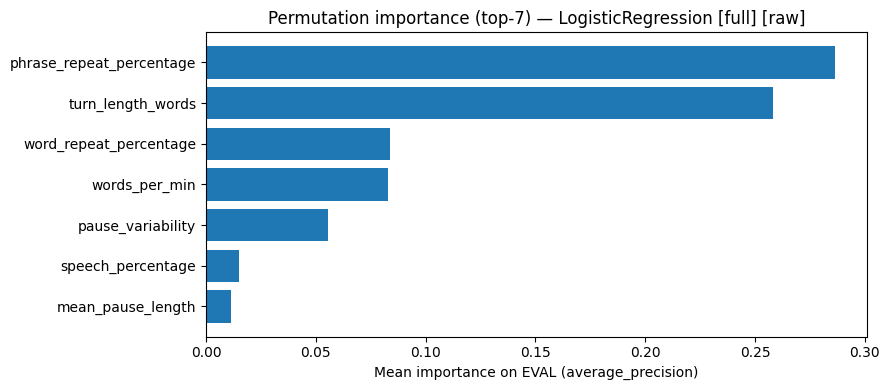


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['turn_length_words', 'phrase_repeat_percentage', 'mean_pause_length', 'word_repeat_percentage']
Train+Dev CV PR AUC: 0.49102749024039394 +/- 0.07789996738503482

Classification report:
               precision    recall  f1-score   support

           0      0.833     0.571     0.678        35
           1      0.531     0.810     0.642        21

    accuracy                          0.661        56
   macro avg      0.682     0.690     0.660        56
weighted avg      0.720     0.661     0.664        56

Confusion matrix:
 [[20 15]
 [ 4 17]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.232657        0.030320
       turn_length_words         0.231758        0.062824
 

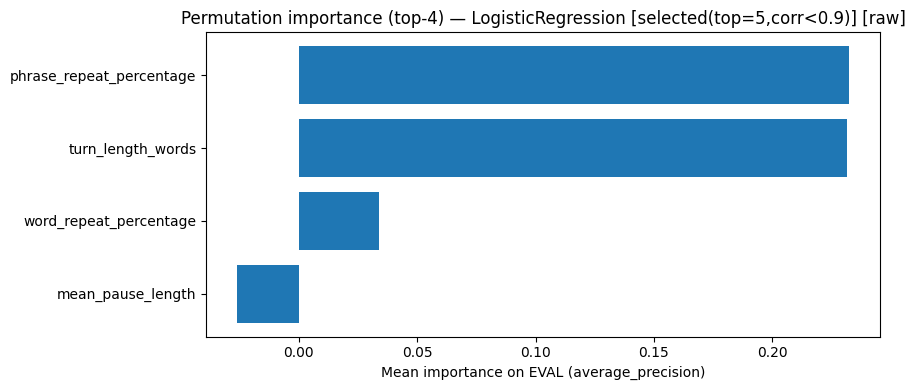


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Best CV score: 0.4652 Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.4651925065495652 +/- 0.04757294720607192

Classification report:
               precision    recall  f1-score   support

           0      0.909     0.571     0.702        35
           1      0.559     0.905     0.691        21

    accuracy                          0.696        56
   macro avg      0.734     0.738     0.696        56
weighted avg      0.778     0.696     0.698        56

Confusion matrix:
 [[20 15]
 [ 2 19]]

[SVM [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.271180        0.029935
       turn_length_words         0.217169        0.064123
           words_per_min         0.063310        0.029344
  word_repeat_per

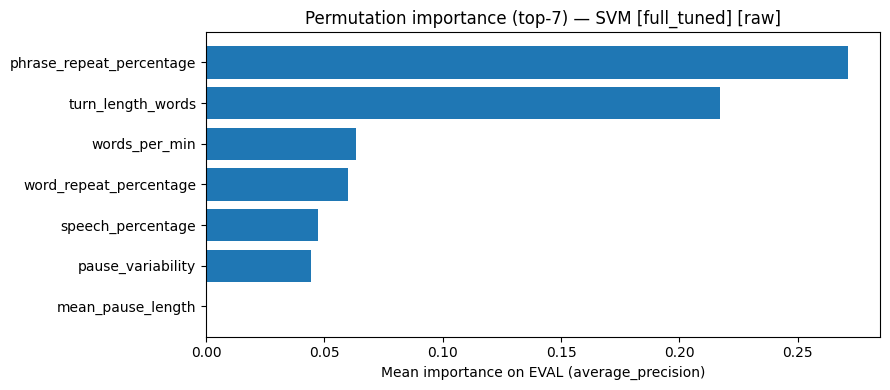


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['turn_length_words', 'words_per_min', 'phrase_repeat_percentage', 'pause_variability', 'speech_percentage']
Best CV score: 0.4686 Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.46859688574983827 +/- 0.03464006156705058

Classification report:
               precision    recall  f1-score   support

           0      0.846     0.629     0.721        35
           1      0.567     0.810     0.667        21

    accuracy                          0.696        56
   macro avg      0.706     0.719     0.694        56
weighted avg      0.741     0.696     0.701        56

Confusion matrix:
 [[22 13]
 [ 4 17]]

[SVM [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.206950        0.074390

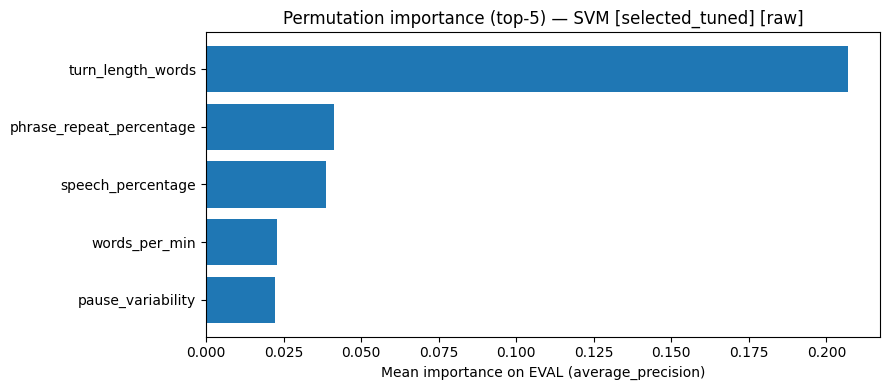


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Train+Dev CV PR AUC: 0.3833112154707338 +/- 0.12238492327863944

Classification report:
               precision    recall  f1-score   support

           0      0.595     0.629     0.611        35
           1      0.316     0.286     0.300        21

    accuracy                          0.500        56
   macro avg      0.455     0.457     0.456        56
weighted avg      0.490     0.500     0.494        56

Confusion matrix:
 [[22 13]
 [15  6]]

[SGDClassifier(log_loss) [full]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.062142        0.013683
       turn_length_words         0.003061        0.002398
       speech_percentage        -0.002460        0.012323
       pause_variability        -0.020554        0.031364
           words_per_min    

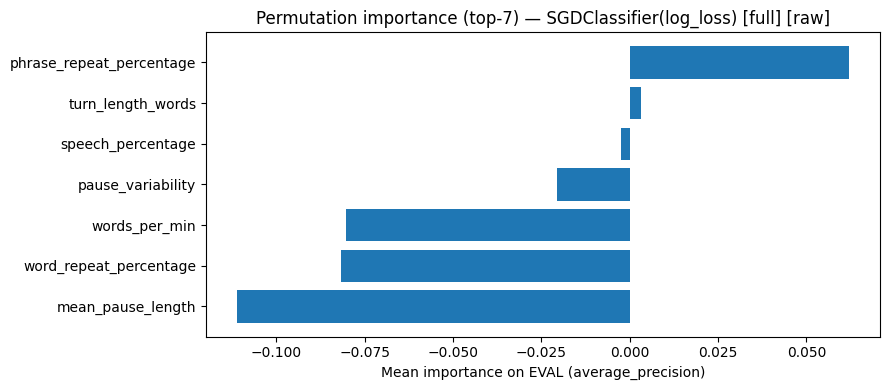


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['turn_length_words', 'pause_variability', 'phrase_repeat_percentage', 'word_repeat_percentage']
Train+Dev CV PR AUC: 0.36422750816264127 +/- 0.12336780072897319

Classification report:
               precision    recall  f1-score   support

           0      0.767     0.657     0.708        35
           1      0.538     0.667     0.596        21

    accuracy                          0.661        56
   macro avg      0.653     0.662     0.652        56
weighted avg      0.681     0.661     0.666        56

Confusion matrix:
 [[23 12]
 [ 7 14]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.232168        0.073368
  word_repeat_percentage         0.018195        

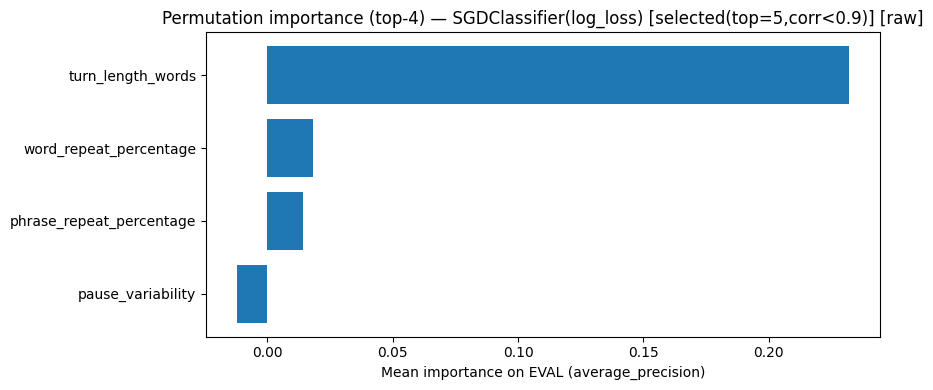


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Best CV score: 0.3765 Best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10}
Train+Dev CV PR AUC: 0.37653771184802365 +/- 0.04988371537443736

Classification report:
               precision    recall  f1-score   support

           0      0.633     0.543     0.585        35
           1      0.385     0.476     0.426        21

    accuracy                          0.518        56
   macro avg      0.509     0.510     0.505        56
weighted avg      0.540     0.518     0.525        56

Confusion matrix:
 [[19 16]
 [11 10]]

[DecisionTree [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.056614        0.013539
phrase_repeat_percentage         0.014330        0.008642
       mean_pause_length         0.

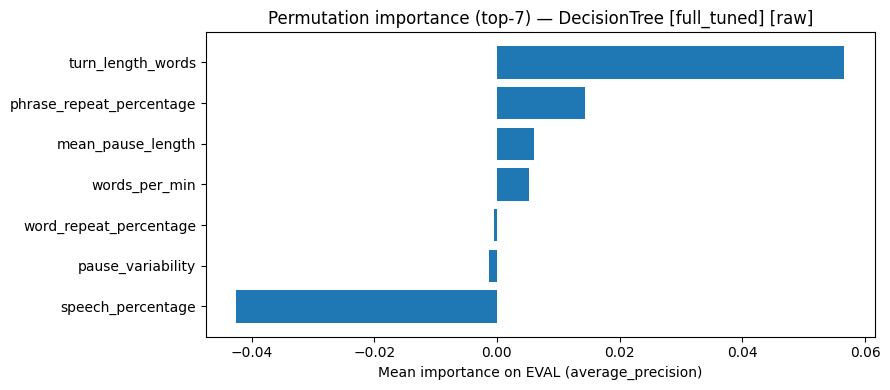


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['words_per_min', 'speech_percentage', 'word_repeat_percentage', 'turn_length_words', 'pause_variability']
Best CV score: 0.4014 Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.4014291324856439 +/- 0.055766729938769535

Classification report:
               precision    recall  f1-score   support

           0      0.652     0.429     0.517        35
           1      0.394     0.619     0.481        21

    accuracy                          0.500        56
   macro avg      0.523     0.524     0.499        56
weighted avg      0.555     0.500     0.504        56

Confusion matrix:
 [[15 20]
 [ 8 13]]

[DecisionTree [selected_tuned]] Top-5 permutation importances (average_precision, raw):
               feature  importance_mean  importance_std
     turn_length_words    

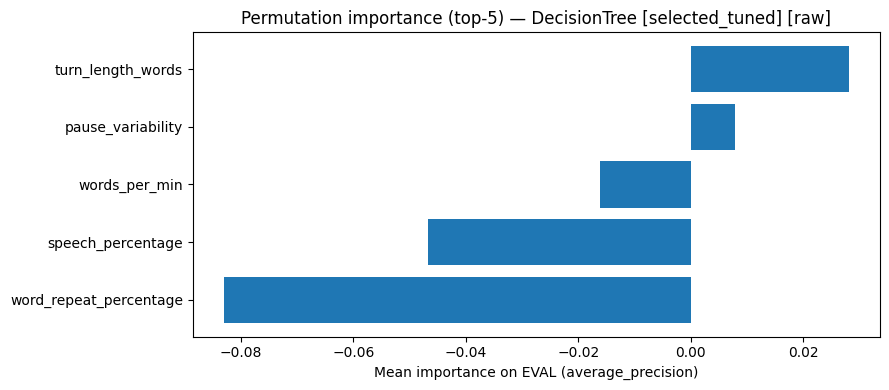


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Best CV score: 0.3966 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}
Train+Dev CV PR AUC: 0.39661244017648845 +/- 0.047579344623331174

Classification report:
               precision    recall  f1-score   support

           0      0.750     0.686     0.716        35
           1      0.542     0.619     0.578        21

    accuracy                          0.661        56
   macro avg      0.646     0.652     0.647        56
weighted avg      0.672     0.661     0.664        56

Confusion matrix:
 [[24 11]
 [ 8 13]]

[RandomForest [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.078945        0.051394
phrase_repeat_pe

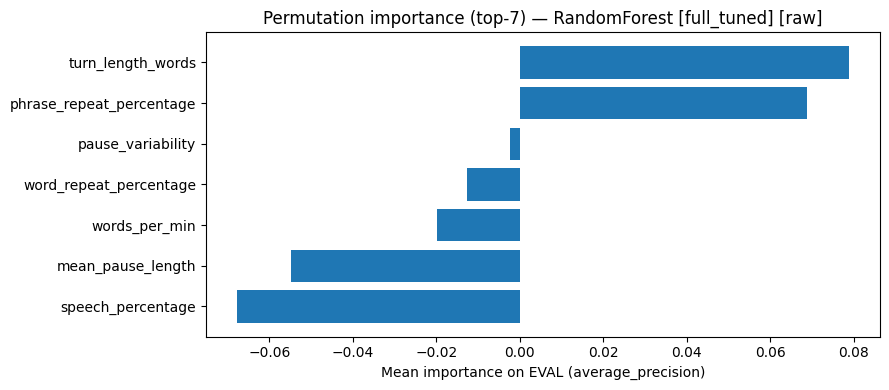


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['words_per_min', 'turn_length_words', 'pause_variability', 'speech_percentage', 'phrase_repeat_percentage']
Best CV score: 0.4242 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}
Train+Dev CV PR AUC: 0.4242367864559153 +/- 0.03665418055160629

Classification report:
               precision    recall  f1-score   support

           0      0.793     0.657     0.719        35
           1      0.556     0.714     0.625        21

    accuracy                          0.679        56
   macro avg      0.674     0.686     0.672        56
weighted avg      0.704     0.679     0.684        56

Confusion matrix:
 [[23 12]
 [ 6 15]]

[RandomForest [selected_tuned]] Top-5 permutation importances (average_precision, raw):
  

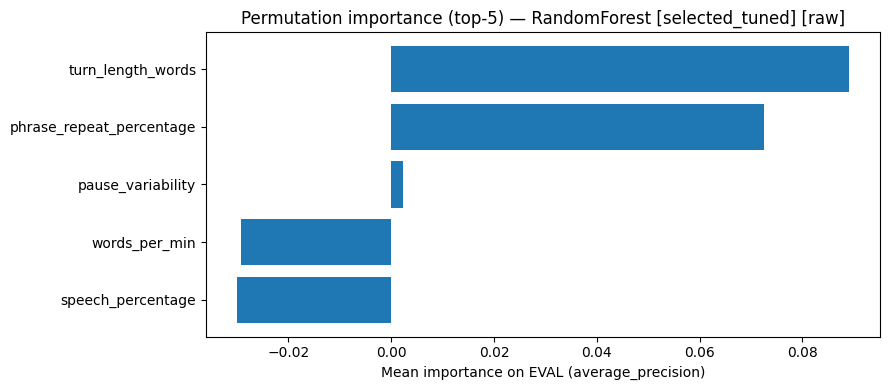


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Best CV score: 0.3922 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.39222451699942373 +/- 0.047094480032248545

Classification report:
               precision    recall  f1-score   support

           0      0.727     0.457     0.561        35
           1      0.441     0.714     0.545        21

    accuracy                          0.554        56
   macro avg      0.584     0.586     0.553        56
weighted avg      0.620     0.554     0.555        56

Confusion matrix:
 [[16 19]
 [ 6 15]]

[XGBoost [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.058360        0.026451
    

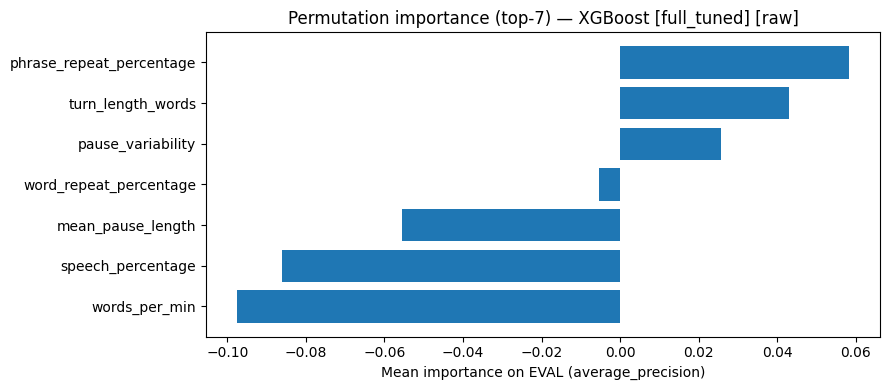


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['words_per_min', 'turn_length_words', 'speech_percentage', 'pause_variability', 'phrase_repeat_percentage']
Best CV score: 0.4656 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV PR AUC: 0.465617639057498 +/- 0.06709892802810292

Classification report:
               precision    recall  f1-score   support

           0      0.773     0.486     0.596        35
           1      0.471     0.762     0.582        21

    accuracy                          0.589        56
   macro avg      0.622     0.624     0.589        56
weighted avg      0.659     0.589     0.591        56

Confusion matrix:
 [[17 18]
 [ 5 16]]

[XGBoost [selected_tuned]] Top-5 permutation importances (average_precisio

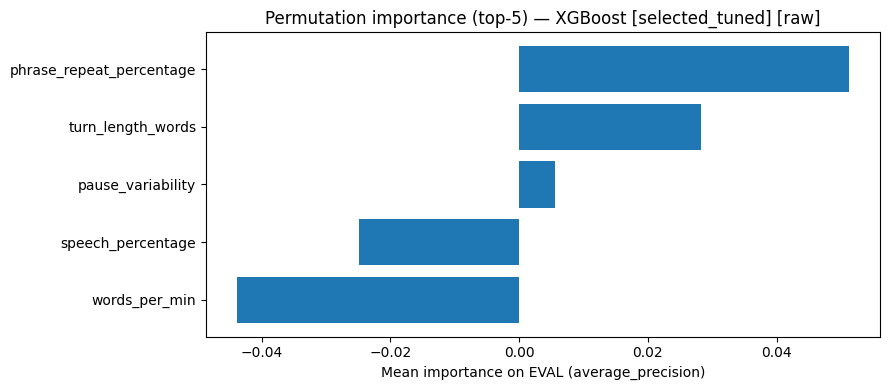


=== Summary metrics on TEST (tuned by PR AUC) ===
    target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                selected_cols
PTSD_label      LogisticRegression                     full  False            NaN          0.4796         0.0615                                                                                                                                                                                           219      56               7                  NaN    0.6607    0.6606 0.5357 0.7678        0.7000   0.7755  0.6339  0.8980

In [4]:
res_b0_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    target_col="PTSD_label",
    importance_top_k=5,
)


In [5]:
res_b0_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.479643,0.061513,,219,56,...,0.660606,0.535714,0.767783,0.700000,0.775510,0.633946,0.897959,0.700697,0.213645,
1,PTSD_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.491027,0.077900,,219,56,...,0.659738,0.535714,0.781299,0.690476,0.723810,0.578197,0.861259,0.620350,0.221877,"turn_length_words,phrase_repeat_percentage,mea..."
2,PTSD_label,SVM,full_tuned,True,0.465193,0.465193,0.047573,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",219,56,...,0.696332,0.582766,0.803006,0.738095,0.763265,0.621735,0.889796,0.679419,0.209030,
3,PTSD_label,SVM,selected_tuned,True,0.468597,0.468597,0.034640,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke...",219,56,...,0.693989,0.570881,0.802018,0.719048,0.782313,0.643537,0.907483,0.685657,0.202633,"turn_length_words,words_per_min,phrase_repeat_..."
4,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.383311,0.122385,,219,56,...,0.455556,0.326692,0.580952,0.457143,0.448980,0.292517,0.604116,0.348701,0.387238,
5,PTSD_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.364228,0.123368,,219,56,...,0.651718,0.520422,0.765992,0.661905,0.761905,0.628571,0.874830,0.673616,0.275362,"turn_length_words,pause_variability,phrase_rep..."
6,PTSD_label,DecisionTree,full_tuned,True,0.376538,0.376538,0.049884,"{'clf__max_depth': None, 'clf__min_samples_lea...",219,56,...,0.505074,0.372859,0.635417,0.509524,0.534694,0.386395,0.685051,0.391765,0.406184,
7,PTSD_label,DecisionTree,selected_tuned,True,0.401429,0.401429,0.055767,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",219,56,...,0.499361,0.373201,0.623921,0.523810,0.528571,0.378912,0.676922,0.380195,0.317858,"words_per_min,speech_percentage,word_repeat_pe..."
8,PTSD_label,RandomForest,full_tuned,True,0.396612,0.396612,0.047579,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.647098,0.513369,0.771528,0.652381,0.648980,0.496599,0.797313,0.523973,0.230091,
9,PTSD_label,RandomForest,selected_tuned,True,0.424237,0.424237,0.036654,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.671875,0.546485,0.795688,0.685714,0.673469,0.523776,0.817721,0.553172,0.225299,"words_per_min,turn_length_words,pause_variabil..."



[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 13) | X_test shape: (56, 13)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Train+Dev CV PR AUC: 0.6019121773808964 +/- 0.07866116648039073

Classification report:
               precision    recall  f1-score   support

           0      0.731     0.543     0.623        35
           1      0.467     0.667     0.549        21

    accuracy                          0.589        56
   macro avg      0.599     0.605     0.586        56
weighted avg      0.632     0.589     0.595        56

Confusion matrix:
 [[19 16]
 [ 7 14]]

[LogisticRegression [full]] Top-10 permutation importances (average_precision, raw):
                               feat

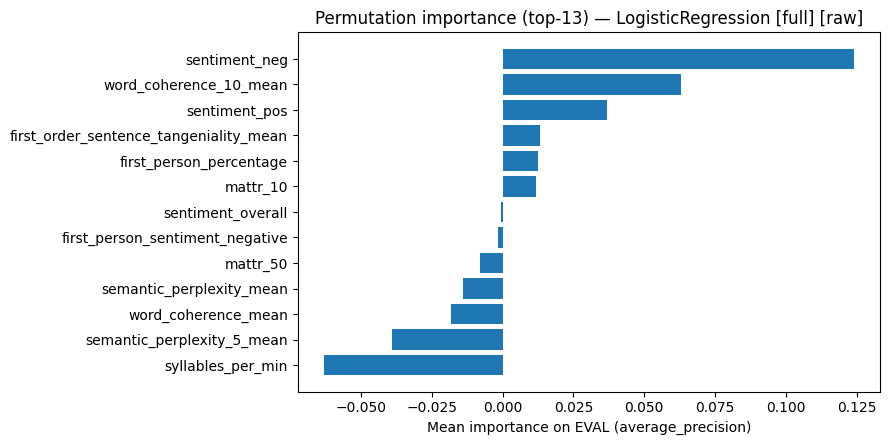


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['word_coherence_10_mean', 'sentiment_neg', 'semantic_perplexity_5_mean', 'sentiment_pos', 'semantic_perplexity_mean']
Train+Dev CV PR AUC: 0.5904571535561901 +/- 0.05830076511516112

Classification report:
               precision    recall  f1-score   support

           0      0.818     0.514     0.632        35
           1      0.500     0.810     0.618        21

    accuracy                          0.625        56
   macro avg      0.659     0.662     0.625        56
weighted avg      0.699     0.625     0.627        56

Confusion matrix:
 [[18 17]
 [ 4 17]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
                   feature  importance_mean  importance_std
             sentiment_neg         0.142925        0.036759
    word_coherence_10_mean         

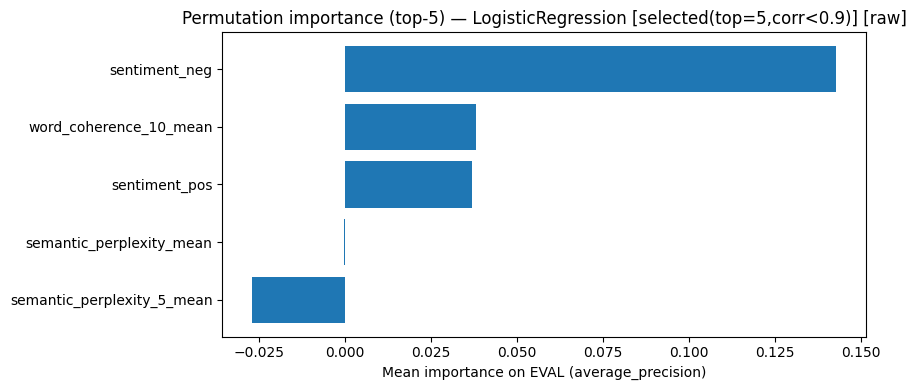


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Best CV score: 0.6072 Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.6072023004988554 +/- 0.10392410840826352

Classification report:
               precision    recall  f1-score   support

           0      0.731     0.543     0.623        35
           1      0.467     0.667     0.549        21

    accuracy                          0.589        56
   macro avg      0.599     0.605     0.586        56
weighted avg      0.632     0.589     0.595        56

Confusion matrix:
 [[19 16]
 [ 7 14]]

[SVM [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg         0.117310        0.025846
                word_coherence_10_mean         0.058835        0.024200
                         sentimen

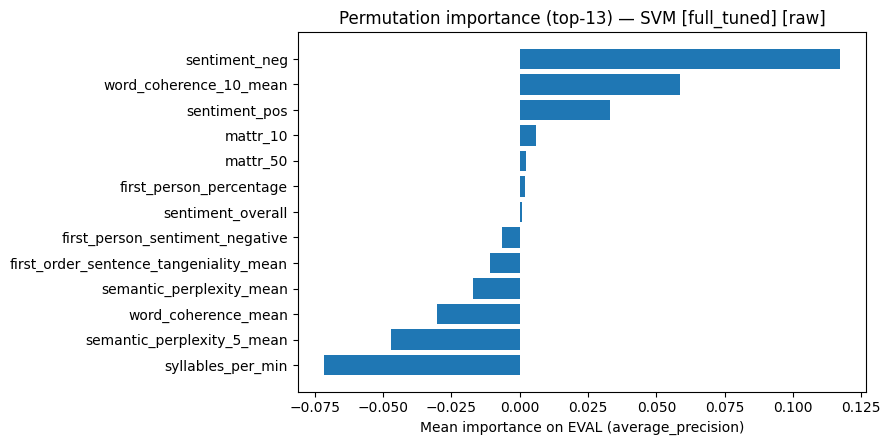


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['sentiment_neg', 'syllables_per_min', 'sentiment_pos', 'semantic_perplexity_5_mean', 'first_person_sentiment_negative']
Best CV score: 0.5429 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.5428784760153157 +/- 0.04335879100994701

Classification report:
               precision    recall  f1-score   support

           0      0.800     0.457     0.582        35
           1      0.472     0.810     0.596        21

    accuracy                          0.589        56
   macro avg      0.636     0.633     0.589        56
weighted avg      0.677     0.589     0.587        56

Confusion matrix:
 [[16 19]
 [ 4 17]]

[SVM [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                        feature  importance_mean  importance_std
                  sentiment_neg        

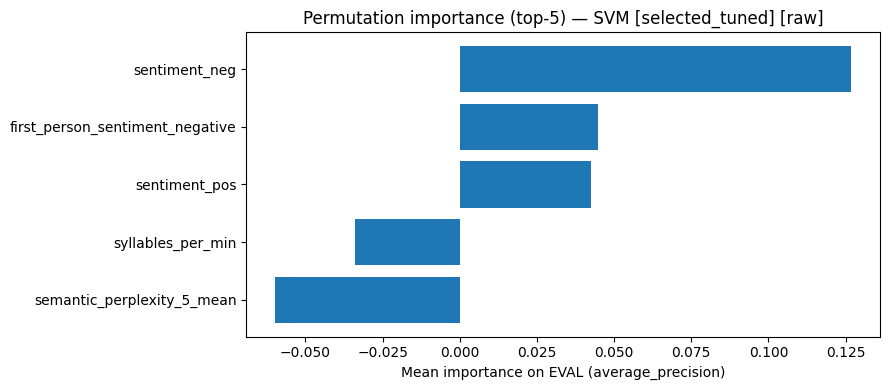


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Train+Dev CV PR AUC: 0.5759568956068671 +/- 0.05022650706511085

Classification report:
               precision    recall  f1-score   support

           0      0.675     0.771     0.720        35
           1      0.500     0.381     0.432        21

    accuracy                          0.625        56
   macro avg      0.588     0.576     0.576        56
weighted avg      0.609     0.625     0.612        56

Confusion matrix:
 [[27  8]
 [13  8]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           sentiment_neg         0.089166        0.019640
  word_coherence_10_mean         0.050151        0.031246
           sentiment_pos         0.018245        0.011502
                mattr_10         0.001235        0.000948
 first_person_percentage    

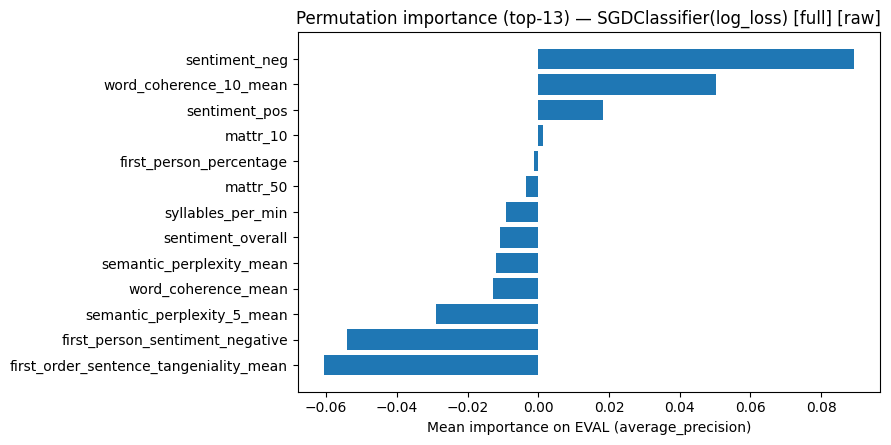


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['word_coherence_10_mean', 'sentiment_neg', 'semantic_perplexity_5_mean', 'sentiment_pos']
Train+Dev CV PR AUC: 0.49273801557799385 +/- 0.09316403672070435

Classification report:
               precision    recall  f1-score   support

           0      0.833     0.714     0.769        35
           1      0.615     0.762     0.681        21

    accuracy                          0.732        56
   macro avg      0.724     0.738     0.725        56
weighted avg      0.752     0.732     0.736        56

Confusion matrix:
 [[25 10]
 [ 5 16]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
                   feature  importance_mean  importance_std
             sentiment_neg         0.154790        0.053691
    word_coherence_10_mean         0.002940        0

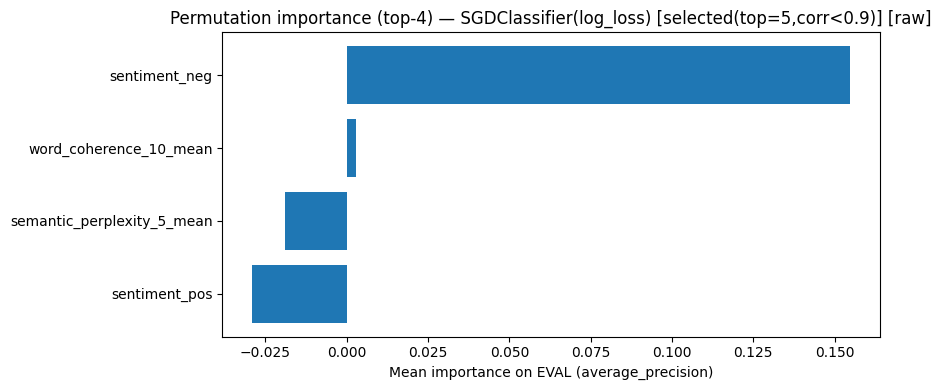


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Best CV score: 0.457 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10}
Train+Dev CV PR AUC: 0.4570120702321102 +/- 0.12371988094678671

Classification report:
               precision    recall  f1-score   support

           0      0.618     0.600     0.609        35
           1      0.364     0.381     0.372        21

    accuracy                          0.518        56
   macro avg      0.491     0.490     0.490        56
weighted avg      0.522     0.518     0.520        56

Confusion matrix:
 [[21 14]
 [13  8]]

[DecisionTree [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg         0.066233        0.048795
                         sentiment_pos         0.008668        0.01103

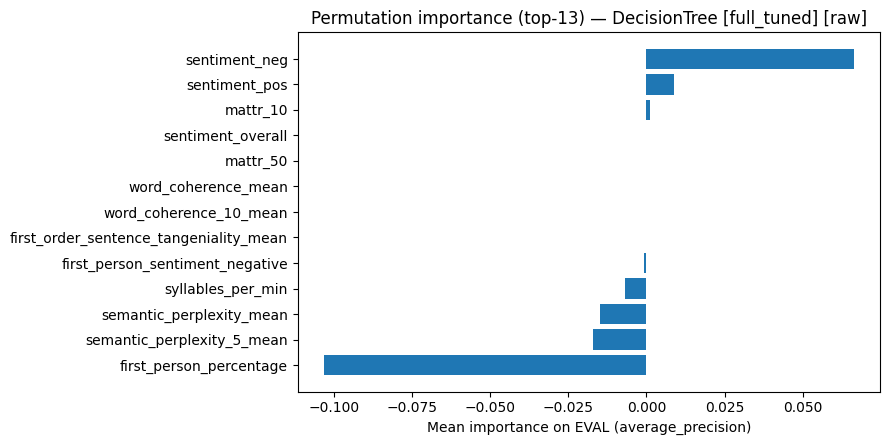


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['sentiment_neg', 'semantic_perplexity_mean', 'semantic_perplexity_5_mean', 'sentiment_overall', 'sentiment_pos']
Best CV score: 0.5086 Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.5086125026697882 +/- 0.07632166639491926

Classification report:
               precision    recall  f1-score   support

           0      0.607     0.486     0.540        35
           1      0.357     0.476     0.408        21

    accuracy                          0.482        56
   macro avg      0.482     0.481     0.474        56
weighted avg      0.513     0.482     0.490        56

Confusion matrix:
 [[17 18]
 [11 10]]

[DecisionTree [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                   feature  importance_mean  importance_std
             sent

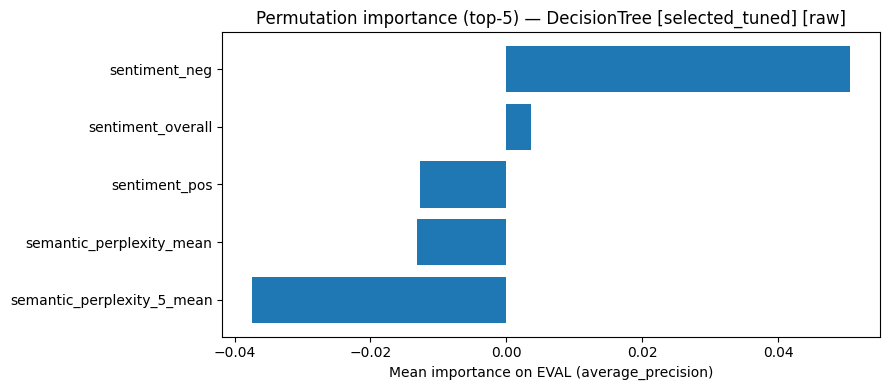


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Best CV score: 0.5393 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.5393071631879425 +/- 0.1009818122061578

Classification report:
               precision    recall  f1-score   support

           0      0.690     0.829     0.753        35
           1      0.571     0.381     0.457        21

    accuracy                          0.661        56
   macro avg      0.631     0.605     0.605        56
weighted avg      0.646     0.661     0.642        56

Confusion matrix:
 [[29  6]
 [13  8]]

[RandomForest [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg         0.116025        0.0

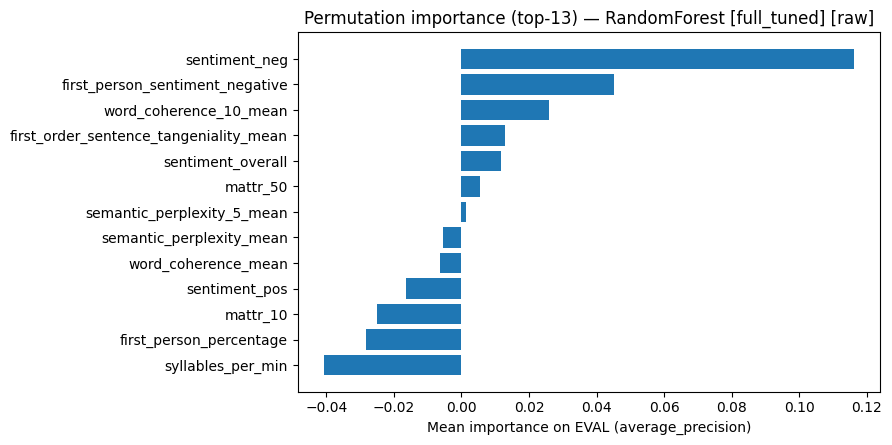


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['sentiment_neg', 'mattr_10', 'semantic_perplexity_mean', 'syllables_per_min', 'sentiment_pos']
Best CV score: 0.5687 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}
Train+Dev CV PR AUC: 0.5686837693156186 +/- 0.07213212433727527

Classification report:
               precision    recall  f1-score   support

           0      0.657     0.657     0.657        35
           1      0.429     0.429     0.429        21

    accuracy                          0.571        56
   macro avg      0.543     0.543     0.543        56
weighted avg      0.571     0.571     0.571        56

Confusion matrix:
 [[23 12]
 [12  9]]

[RandomForest [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                

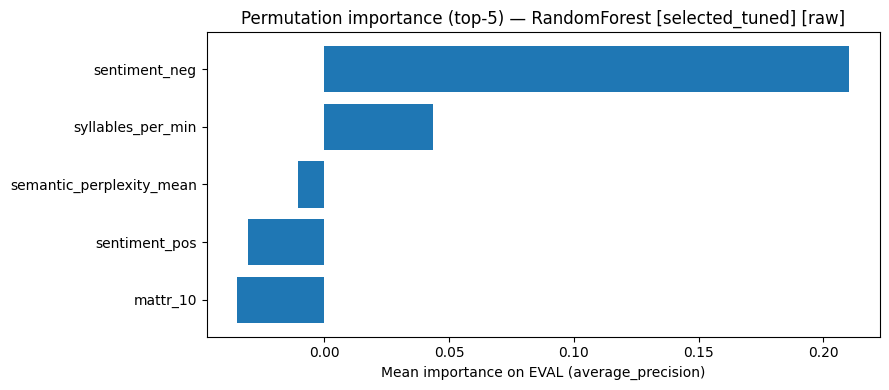


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Best CV score: 0.5224 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.5223819765038831 +/- 0.08326559505767565

Classification report:
               precision    recall  f1-score   support

           0      0.636     0.800     0.709        35
           1      0.417     0.238     0.303        21

    accuracy                          0.589        56
   macro avg      0.527     0.519     0.506        56
weighted avg      0.554     0.589     0.557        56

Confusion matrix:
 [[28  7]
 [16  5]]

[XGBoost [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
       first_person_sentiment_negative         0.03

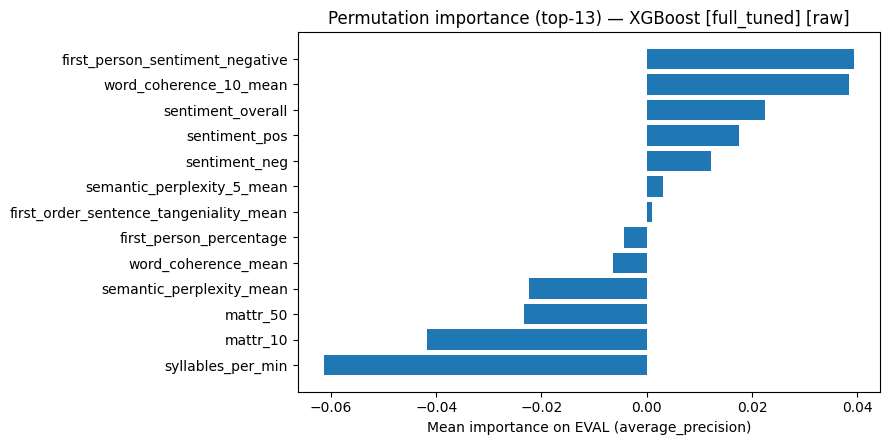


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['sentiment_neg', 'semantic_perplexity_mean', 'mattr_10', 'word_coherence_10_mean', 'semantic_perplexity_5_mean']
Best CV score: 0.5705 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.5705122577244512 +/- 0.14253594888443846

Classification report:
               precision    recall  f1-score   support

           0      0.684     0.743     0.712        35
           1      0.500     0.429     0.462        21

    accuracy                          0.625        56
   macro avg      0.592     0.586     0.587        56
weighted avg      0.615     0.625     0.618        56

Confusion matrix:
 [[26  9]
 [12  9]]

[XGBoost [selected_tuned]] Top-5 permutation importances (average_prec

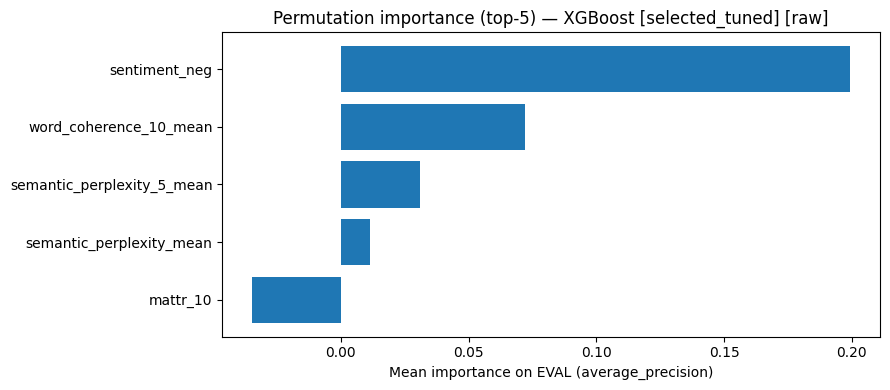


=== Summary metrics on TEST (tuned by PR AUC) ===
    target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                         best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                            selected_cols
PTSD_label      LogisticRegression                     full  False            NaN          0.6019         0.0787                                                                                                                                                                                          219      56              13                  NaN    0.5893    0.5860 0.4581 0.7110        0.6048   0.6490  0.49

In [6]:
res_l_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    target_col="PTSD_label",
    importance_top_k=5,
)

In [7]:
res_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.601912,0.078661,,219,56,...,0.585985,0.458065,0.710968,0.604762,0.648980,0.495238,0.794592,0.471478,0.262643,
1,PTSD_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.590457,0.058301,,219,56,...,0.624880,0.497436,0.744792,0.661905,0.658503,0.507483,0.798639,0.507060,0.262505,"word_coherence_10_mean,sentiment_neg,semantic_..."
2,PTSD_label,SVM,full_tuned,True,0.607202,0.607202,0.103924,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",219,56,...,0.585985,0.458065,0.710968,0.604762,0.638095,0.481599,0.779660,0.457260,0.232258,
3,PTSD_label,SVM,selected_tuned,True,0.542878,0.542878,0.043359,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.589155,0.463602,0.696332,0.633333,0.687075,0.544218,0.815034,0.574882,0.211402,"sentiment_neg,syllables_per_min,sentiment_pos,..."
4,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.575957,0.050227,,219,56,...,0.576216,0.442116,0.704953,0.576190,0.523810,0.359184,0.687109,0.426567,0.365221,
5,PTSD_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.492738,0.093164,,219,56,...,0.725041,0.598958,0.835025,0.738095,0.746939,0.614932,0.859864,0.568987,0.245891,"word_coherence_10_mean,sentiment_neg,semantic_..."
6,PTSD_label,DecisionTree,full_tuned,True,0.457012,0.457012,0.123720,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.490394,0.362731,0.619121,0.490476,0.525850,0.369388,0.685731,0.427727,0.375877,
7,PTSD_label,DecisionTree,selected_tuned,True,0.508613,0.508613,0.076322,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",219,56,...,0.473923,0.343750,0.602581,0.480952,0.521088,0.357823,0.678912,0.444399,0.333430,"sentiment_neg,semantic_perplexity_mean,semanti..."
8,PTSD_label,RandomForest,full_tuned,True,0.539307,0.539307,0.100982,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.605195,0.467763,0.733333,0.604762,0.654422,0.495238,0.789150,0.566297,0.216771,
9,PTSD_label,RandomForest,selected_tuned,True,0.568684,0.568684,0.072132,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.542857,0.402560,0.672965,0.542857,0.598639,0.435340,0.752381,0.562608,0.232869,"sentiment_neg,mattr_10,semantic_perplexity_mea..."



[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 20) | X_test shape: (56, 20)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Train+Dev CV PR AUC: 0.6427832412133053 +/- 0.10026100655932495

Classification report:
               precision    recall  f1-score   support

           0      0.769     0.571     0.656        35
           1      0.500     0.714     0.588        21

    accuracy                          0.625        56
   macro avg      0.635     0.643     0.622        56
weighted avg      0.668     0.625     0.630        56

Confusion matrix:
 [[20 15]
 [ 6 15]]

[LogisticRegression [full]] Top-10 permutation importances (average_precision, raw):
                               fe

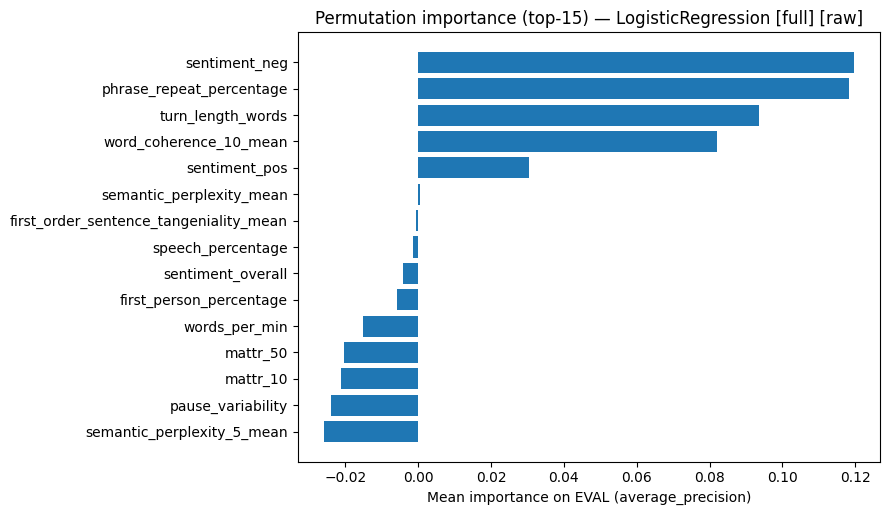


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['word_coherence_10_mean', 'sentiment_neg', 'semantic_perplexity_5_mean', 'turn_length_words', 'phrase_repeat_percentage']
Train+Dev CV PR AUC: 0.6187115535188037 +/- 0.08246845752472079

Classification report:
               precision    recall  f1-score   support

           0      0.931     0.771     0.844        35
           1      0.704     0.905     0.792        21

    accuracy                          0.821        56
   macro avg      0.817     0.838     0.818        56
weighted avg      0.846     0.821     0.824        56

Confusion matrix:
 [[27  8]
 [ 2 19]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
                   feature  importance_mean  importance_std
             sentiment_neg         0.220887        0.054363
         turn_length_words   

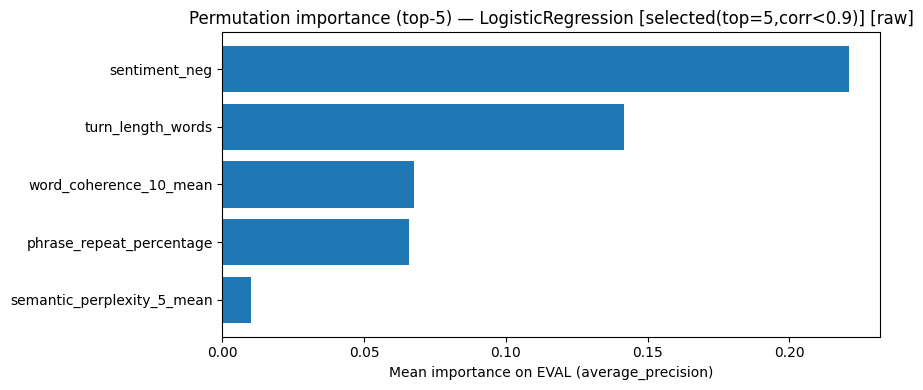


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Best CV score: 0.6313 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.6312753533560758 +/- 0.06426910003139386

Classification report:
               precision    recall  f1-score   support

           0      0.828     0.686     0.750        35
           1      0.593     0.762     0.667        21

    accuracy                          0.714        56
   macro avg      0.710     0.724     0.708        56
weighted avg      0.739     0.714     0.719        56

Confusion matrix:
 [[24 11]
 [ 5 16]]

[SVM [full_tuned]] Top-10 permutation importances (average_precision, raw):
                        feature  importance_mean  importance_std
       phrase_repeat_percentage         0.138822        0.028127
                  sentiment_neg         0.135488        0.066666
              turn_length_words         0.101915  

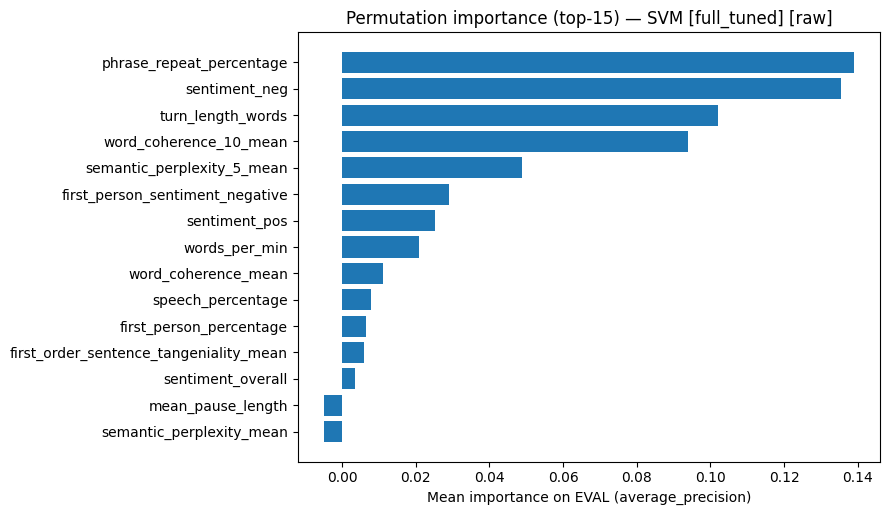


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['sentiment_neg', 'sentiment_pos', 'word_coherence_10_mean', 'turn_length_words', 'semantic_perplexity_mean']
Best CV score: 0.6089 Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.6089432730818517 +/- 0.056432991552807045

Classification report:
               precision    recall  f1-score   support

           0      0.839     0.743     0.788        35
           1      0.640     0.762     0.696        21

    accuracy                          0.750        56
   macro avg      0.739     0.752     0.742        56
weighted avg      0.764     0.750     0.753        56

Confusion matrix:
 [[26  9]
 [ 5 16]]

[SVM [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           sentiment_neg         0.291765        0.0573

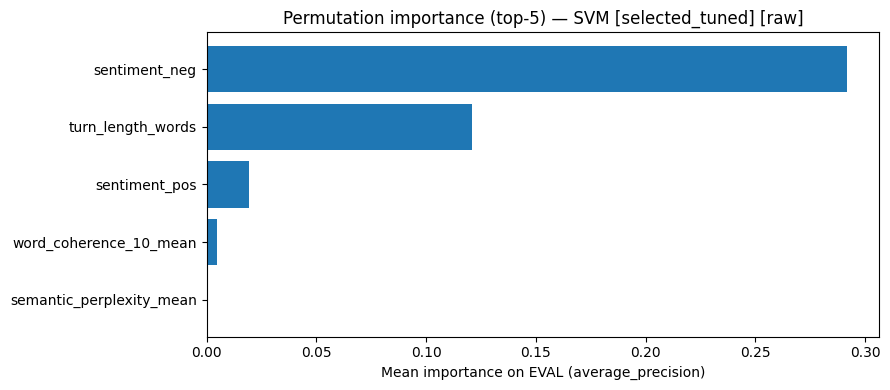


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Train+Dev CV PR AUC: 0.562914824431964 +/- 0.1466002680212083

Classification report:
               precision    recall  f1-score   support

           0      0.704     0.543     0.613        35
           1      0.448     0.619     0.520        21

    accuracy                          0.571        56
   macro avg      0.576     0.581     0.566        56
weighted avg      0.608     0.571     0.578        56

Confusion matrix:
 [[19 16]
 [ 8 13]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              phrase_repeat_percentage         0.067303        0.023581
                     turn_length_words         0.055900        0.014533
                         sentiment_neg         0.036339        0.010378
                word_coherence

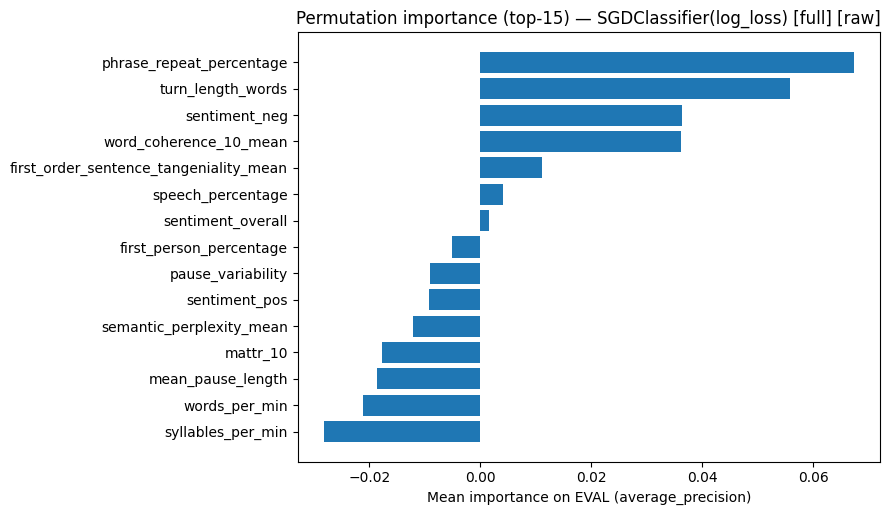


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['sentiment_neg', 'word_coherence_10_mean', 'semantic_perplexity_5_mean', 'turn_length_words']
Train+Dev CV PR AUC: 0.5017424103108044 +/- 0.10934874889274969

Classification report:
               precision    recall  f1-score   support

           0      0.900     0.514     0.655        35
           1      0.528     0.905     0.667        21

    accuracy                          0.661        56
   macro avg      0.714     0.710     0.661        56
weighted avg      0.760     0.661     0.659        56

Confusion matrix:
 [[18 17]
 [ 2 19]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
                   feature  importance_mean  importance_std
         turn_length_words         0.277065        0.073515
             sentiment_neg         0.200687    

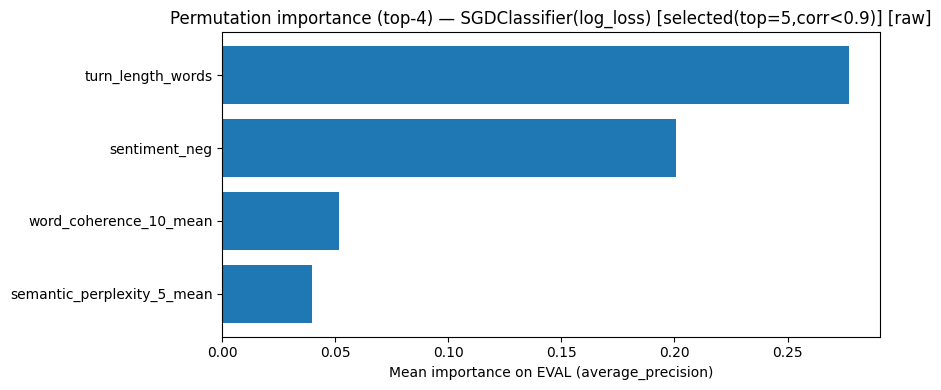


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Best CV score: 0.3868 Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.386799236131448 +/- 0.06340055130026102

Classification report:
               precision    recall  f1-score   support

           0      0.656     0.600     0.627        35
           1      0.417     0.476     0.444        21

    accuracy                          0.554        56
   macro avg      0.536     0.538     0.536        56
weighted avg      0.566     0.554     0.558        56

Confusion matrix:
 [[21 14]
 [11 10]]

[DecisionTree [full_tuned]] Top-10 permutation importances (average_precision, raw):
                   feature  importance_mean  importance_std
             sentiment_neg         0.082164        0.029615
  phrase_repeat_percentage         0.061653        0.023179
         turn_length_words      

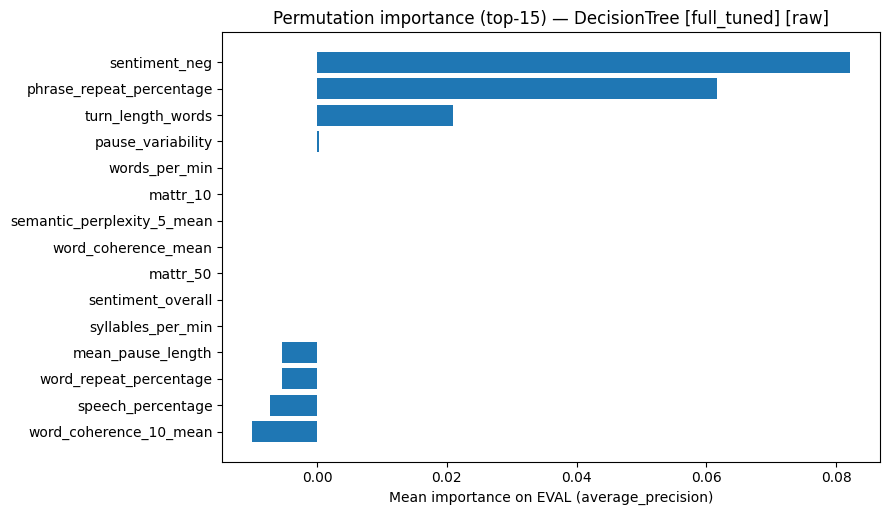


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['sentiment_neg', 'first_person_sentiment_negative', 'semantic_perplexity_mean', 'words_per_min', 'sentiment_pos']
Best CV score: 0.4554 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.4553700575806706 +/- 0.05881704444066017

Classification report:
               precision    recall  f1-score   support

           0      0.625     0.286     0.392        35
           1      0.375     0.714     0.492        21

    accuracy                          0.446        56
   macro avg      0.500     0.500     0.442        56
weighted avg      0.531     0.446     0.430        56

Confusion matrix:
 [[10 25]
 [ 6 15]]

[DecisionTree [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                        feature  importance_mean  importance_std
          

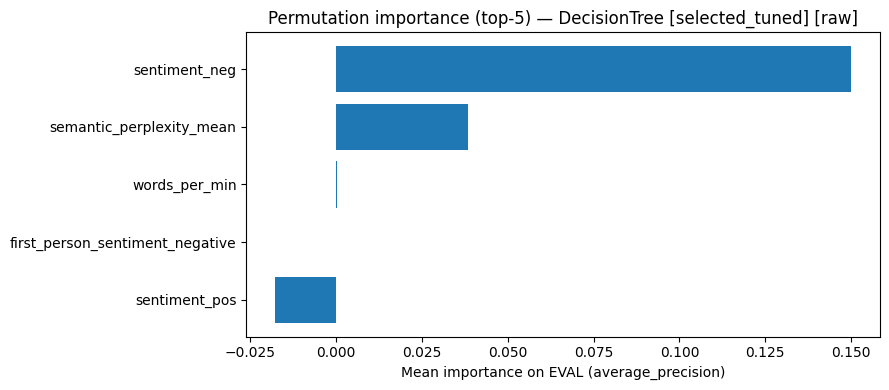


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Best CV score: 0.5542 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.5542183487703134 +/- 0.06760580808691469

Classification report:
               precision    recall  f1-score   support

           0      0.737     0.800     0.767        35
           1      0.611     0.524     0.564        21

    accuracy                          0.696        56
   macro avg      0.674     0.662     0.666        56
weighted avg      0.690     0.696     0.691        56

Confusion matrix:
 [[28  7]
 [10 11]]

[RandomForest [full_tuned]] Top-10 permutation importances (average_precision, raw):
                        feature  importance_mean  importance_std
                  sentiment_neg         0.124491        0.072755
     

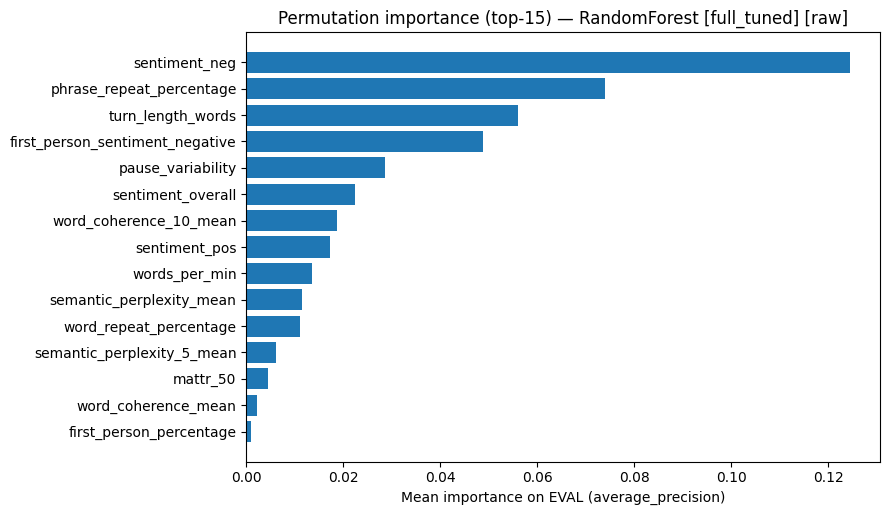


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['sentiment_neg', 'sentiment_pos', 'turn_length_words', 'first_order_sentence_tangeniality_mean', 'mattr_10']
Best CV score: 0.5495 Best params: {'clf__bootstrap': True, 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.5495431075413225 +/- 0.07791589447017325

Classification report:
               precision    recall  f1-score   support

           0      0.711     0.771     0.740        35
           1      0.556     0.476     0.513        21

    accuracy                          0.661        56
   macro avg      0.633     0.624     0.626        56
weighted avg      0.652     0.661     0.655        56

Confusion matrix:
 [[27  8]
 [11 10]]

[RandomForest [selected_tuned]] Top-5 permutation importances (average_precision, raw):

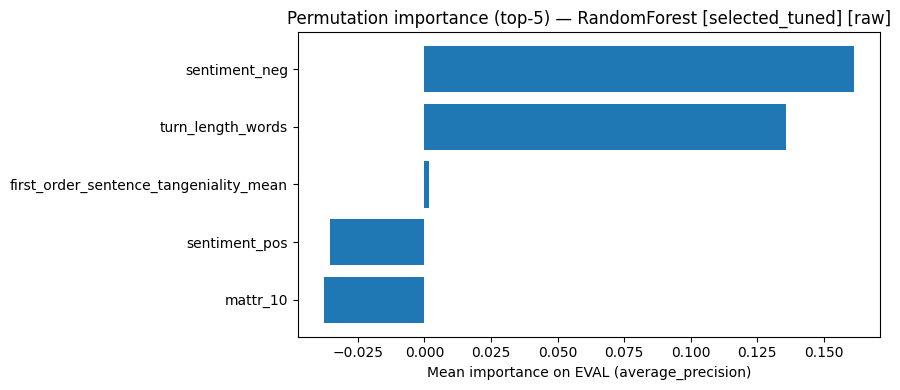


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Best CV score: 0.5013 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.5012927447056681 +/- 0.051492650852553855

Classification report:
               precision    recall  f1-score   support

           0      0.737     0.800     0.767        35
           1      0.611     0.524     0.564        21

    accuracy                          0.696        56
   macro avg      0.674     0.662     0.666        56
weighted avg      0.690     0.696     0.691        56

Confusion matrix:
 [[28  7]
 [10 11]]

[XGBoost [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              phrase_repeat_percentage         0

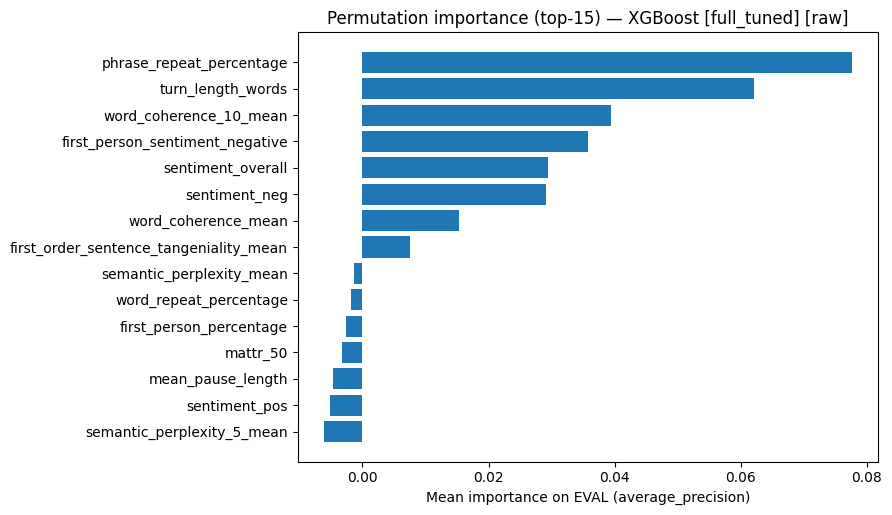


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['sentiment_neg', 'word_coherence_10_mean', 'turn_length_words', 'sentiment_pos', 'sentiment_overall']
Best CV score: 0.5572 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.5572329407079881 +/- 0.069737558447444

Classification report:
               precision    recall  f1-score   support

           0      0.710     0.629     0.667        35
           1      0.480     0.571     0.522        21

    accuracy                          0.607        56
   macro avg      0.595     0.600     0.594        56
weighted avg      0.624     0.607     0.612        56

Confusion matrix:
 [[22 13]
 [ 9 12]]

[XGBoost [selected_tuned]] Top-5 permutation importances (average_precision, raw

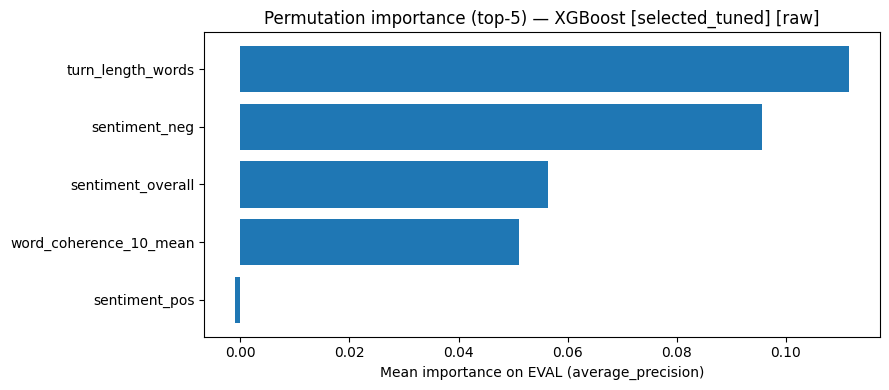


=== Summary metrics on TEST (tuned by PR AUC) ===
    target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                              selected_cols
PTSD_label      LogisticRegression                     full  False            NaN          0.6428         0.1003                                                                                                                                                                                           219      56              20                  NaN    0.6250    0.6220 0.4941 0.7471        0.6429   0.6748  

In [8]:
res_b0_l_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_{LANGUAGE}_full{ITERATION}.csv",
    target_col="PTSD_label",
    importance_top_k=5,
)

In [9]:
res_b0_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.642783,0.100261,,219,56,...,0.621986,0.494078,0.747097,0.642857,0.674830,0.526531,0.813639,0.527187,0.243494,
1,PTSD_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.618712,0.082468,,219,56,...,0.817708,0.721280,0.908347,0.838095,0.861224,0.759150,0.955102,0.724528,0.172751,"word_coherence_10_mean,sentiment_neg,semantic_..."
2,PTSD_label,SVM,full_tuned,True,0.631275,0.631275,0.064269,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.708333,0.588104,0.823151,0.723810,0.793197,0.666633,0.904762,0.666821,0.185112,
3,PTSD_label,SVM,selected_tuned,True,0.608943,0.608943,0.056433,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke...",219,56,...,0.741765,0.631094,0.852437,0.752381,0.801361,0.677517,0.914286,0.755819,0.181492,"sentiment_neg,sentiment_pos,word_coherence_10_..."
4,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.562915,0.146600,,219,56,...,0.566452,0.431751,0.691610,0.580952,0.576871,0.425850,0.723810,0.418815,0.426138,
5,PTSD_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.501742,0.109349,,219,56,...,0.660606,0.541735,0.767783,0.709524,0.834014,0.723776,0.934694,0.775700,0.300303,"sentiment_neg,word_coherence_10_mean,semantic_..."
6,PTSD_label,DecisionTree,full_tuned,True,0.386799,0.386799,0.063401,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",219,56,...,0.535655,0.401361,0.672526,0.538095,0.559864,0.400663,0.720425,0.451963,0.358884,
7,PTSD_label,DecisionTree,selected_tuned,True,0.455370,0.455370,0.058817,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.441980,0.320562,0.553429,0.500000,0.639456,0.473401,0.784371,0.530658,0.273798,"sentiment_neg,first_person_sentiment_negative,..."
8,PTSD_label,RandomForest,full_tuned,True,0.554218,0.554218,0.067606,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.665613,0.533333,0.788400,0.661905,0.662585,0.495238,0.812279,0.649428,0.215573,
9,PTSD_label,RandomForest,selected_tuned,True,0.549543,0.549543,0.077916,"{'clf__bootstrap': True, 'clf__max_depth': 10,...",219,56,...,0.626273,0.493213,0.754634,0.623810,0.682993,0.534694,0.824524,0.618464,0.215320,"sentiment_neg,sentiment_pos,turn_length_words,..."


# fusing pipeline

In [2]:
import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Sequence, Dict, Any, List, Tuple
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False


# -------------------------
# Bootstrap CIs (optional; оставил как у тебя)
# -------------------------
def bootstrap_ci_binary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    metric: str,
    n_boot: int = 2000,
    seed: int = 1706,
    stratified: bool = True,
) -> Tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        return float("nan"), float("nan"), float("nan")

    scores = []
    for _ in range(n_boot):
        if stratified:
            samp_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
            samp_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
            idx = np.concatenate([samp_pos, samp_neg])
        else:
            idx = rng.choice(len(y_true), size=len(y_true), replace=True)

        yt, yp, pr = y_true[idx], y_pred[idx], y_proba[idx]
        if metric == "f1_macro":
            s = f1_score(yt, yp, average="macro")
        elif metric == "auc":
            if len(np.unique(yt)) < 2:
                continue
            s = roc_auc_score(yt, pr)
        else:
            raise ValueError("metric must be 'f1_macro' or 'auc'")
        scores.append(s)

    if not scores:
        return float("nan"), float("nan"), float("nan")

    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(np.mean(scores)), float(lo), float(hi)


# -------------------------
# Clean, leakage-safe late fusion / stacking
# -------------------------
def run_late_fusion_pipeline_clean(
    dataset_b0_path: str,
    dataset_l_path: str,
    *,
    id_col: str = "Participant",
    target_col: str = "PTSD_label",
    split_col: str = "split",
    train_values: Sequence[str] = ("train", "dev"),
    test_value: str = "test",

    # model choice
    base_model_b0: str = "LogisticRegression",
    base_model_l: Optional[str] = None,  # if None -> same as base_model_b0
    meta_C: float = 1.0,

    # leakage-safe drops policy
    drop_demographics: bool = True,          # drop age/gender/sex by default
    extra_drop_common: Optional[Sequence[str]] = None,
    extra_drop_b0: Optional[Sequence[str]] = None,
    extra_drop_l: Optional[Sequence[str]] = None,

    # CV / OOF
    n_splits: int = 5,
    random_state: int = 1706,

    # tuning (if enabled, it will be NESTED in OOF; correct, but slower)
    tune_tree_models: bool = False,
    grid_scoring: str = "average_precision",
    grid_n_jobs: int = 1,
    grid_verbose: int = 0,

    # importance
    compute_importance: bool = True,
    perm_scoring: str = "average_precision",
    perm_n_repeats: int = 10,
    plot_top_k: int = 15,

    # metrics / CIs
    n_boot: int = 2000,
) -> pd.DataFrame:
    """
    What is guaranteed:
      - strict alignment B0<->L by id_col
      - automatic leakage-safe drop based on target_col:
          drops: id_col, split_col, target_col,
                 ALL other *_label / *_severity columns,
                 + optionally demographics
      - base models trained on train+dev; test evaluated on test
      - stacking uses OOF probabilities on train+dev (no test leakage)
      - permutation importance computed on RAW columns (clean and readable)
    """

    if base_model_l is None:
        base_model_l = base_model_b0

    extra_drop_common = list(extra_drop_common or [])
    extra_drop_b0 = list(extra_drop_b0 or [])
    extra_drop_l = list(extra_drop_l or [])

    # ---------- helpers ----------
    def _build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        cat = [c for c in X.columns if X[c].dtype.name in ["object", "category", "bool"]]
        num = [c for c in X.columns if c not in cat]
        try:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

        return ColumnTransformer(
            transformers=[
                ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", ohe)]), cat),
                ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
            ],
            remainder="drop",
        )

    def _safe_n_splits(y: np.ndarray, desired: int) -> int:
        counts = Counter(y.tolist())
        min_class = min(counts.values()) if counts else 0
        return max(2, min(desired, min_class)) if min_class >= 2 else 0

    def _predict_proba(pipe: Pipeline, X: pd.DataFrame) -> np.ndarray:
        return pipe.predict_proba(X)[:, 1]



    def _best_threshold(y_true: np.ndarray, y_proba: np.ndarray, metric: str = "f1") -> float:
        thresholds = np.linspace(0.0, 1.0, 201)
        best_t = 0.5
        best_v = -np.inf
        for t in thresholds:
            y_hat = (y_proba >= t).astype(int)
            if metric == "balanced_acc":
                v = balanced_accuracy_score(y_true, y_hat)
            else:
                v = f1_score(y_true, y_hat, average="macro")
            if v > best_v:
                best_v = v
                best_t = t
        return float(best_t)

    def _metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> Dict[str, Any]:
        out = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
            "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
            "roc_auc": float(roc_auc_score(y_true, y_proba)) if len(np.unique(y_true)) == 2 else float("nan"),
            "pr_auc": float(average_precision_score(y_true, y_proba)) if len(np.unique(y_true)) == 2 else float("nan"),
            "brier": float(brier_score_loss(y_true, y_proba)),
            "f1_lo": float("nan"),
            "f1_hi": float("nan"),
            "auc_lo": float("nan"),
            "auc_hi": float("nan"),
        }
        # bootstrap CI
        if len(np.unique(y_true)) == 2:
            _, f1_lo, f1_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="f1_macro",
                n_boot=n_boot, seed=random_state
            )
            _, auc_lo, auc_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="auc",
                n_boot=n_boot, seed=random_state
            )
            out["f1_lo"], out["f1_hi"] = float(f1_lo), float(f1_hi)
            out["auc_lo"], out["auc_hi"] = float(auc_lo), float(auc_hi)
        return out

    def _perm_importance_raw(pipe_fitted: Pipeline, X_eval: pd.DataFrame, y_eval: np.ndarray, title: str) -> pd.DataFrame:
        perm = permutation_importance(
            pipe_fitted, X_eval, y_eval,
            n_repeats=perm_n_repeats,
            random_state=random_state,
            scoring=perm_scoring
        )
        perm_df = pd.DataFrame({
            "feature": list(X_eval.columns),
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

        print(f"\n[{title}] Top-{min(10, len(perm_df))} permutation importances ({perm_scoring}, raw):")
        print(perm_df.head(10).to_string(index=False))

        top_n = min(plot_top_k, len(perm_df))
        if top_n > 0:
            plt.figure(figsize=(9, max(4, 0.35 * top_n)))
            plt.barh(
                perm_df.loc[:top_n - 1, "feature"][::-1],
                perm_df.loc[:top_n - 1, "importance_mean"][::-1],
            )
            plt.title(f"Permutation importance (top-{top_n}) — {title} [raw]")
            plt.xlabel(f"Mean importance on EVAL ({perm_scoring})")
            plt.tight_layout()
            plt.show()

        return perm_df

    def _make_leakage_drop(df: pd.DataFrame) -> List[str]:
        # drop: id, split, target + all other *_label / *_severity columns
        drops = {id_col, split_col, target_col}

        for c in df.columns:
            lc = str(c).lower()
            if c == target_col:
                continue
            if lc.endswith("_label") or lc.endswith("_severity"):
                drops.add(c)

        if drop_demographics:
            for c in ["age", "gender", "sex"]:
                if c in df.columns:
                    drops.add(c)

        for c in extra_drop_common:
            if c in df.columns:
                drops.add(c)

        return sorted(drops)

    def _assert_no_leakage_cols(X: pd.DataFrame, df_ref: pd.DataFrame, where: str) -> None:
        forbidden = set(_make_leakage_drop(df_ref)) - {id_col, split_col}
        bad = forbidden.intersection(set(X.columns))
        if bad:
            raise ValueError(
                f"[LEAKAGE] Forbidden columns present in features at {where}: {sorted(bad)}. "
                f"Check drop policy / extra_drop_*."
            )

    def _get_estimator_and_grid(model_name: str, y_for_xgb: np.ndarray):
        name = model_name.strip()

        if name == "LogisticRegression":
            est = LogisticRegression(
                solver="lbfgs", max_iter=5000, class_weight="balanced",
                random_state=random_state
            )
            return est, {}

        if name in ["SVM", "SVC"]:
            est = SVC(
                kernel="rbf", C=1.0, gamma="scale", probability=True,
                class_weight="balanced", random_state=random_state
            )
            grid = {
                "C": [0.1, 1, 10],
                "gamma": ["scale", "auto"],
                "kernel": ["rbf", "linear"],
            }
            return est, grid

        if name == "SGDClassifier(log_loss)":
            est = SGDClassifier(
                loss="log_loss", penalty="l2", alpha=1e-4,
                max_iter=5000, tol=1e-3, class_weight="balanced",
                random_state=random_state
            )
            return est, {}

        if name == "DecisionTree":
            est = DecisionTreeClassifier(random_state=random_state, class_weight="balanced")
            grid = {
                "max_depth": [3, 5, 10, None],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4, 8],
            }
            return est, grid

        if name == "RandomForest":
            est = RandomForestClassifier(random_state=random_state, class_weight="balanced", n_jobs=1)
            grid = {
                "n_estimators": [200, 500],
                "max_depth": [None, 5, 10],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "max_features": ["sqrt", "log2", 0.5],
                "bootstrap": [True],
            }
            return est, grid

        if name == "XGBoost":
            if not xgb_available:
                raise RuntimeError("XGBoost requested but xgboost is not installed.")
            pos = int((y_for_xgb == 1).sum())
            neg = int((y_for_xgb == 0).sum())
            spw = float(neg / max(pos, 1)) if pos > 0 else 1.0
            est = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=random_state,
                n_jobs=1,
                scale_pos_weight=spw,
            )
            grid = {
                "n_estimators": [200, 500],
                "max_depth": [3, 6, 10],
                "learning_rate": [0.03, 0.1],
                "subsample": [0.8, 1.0],
                "colsample_bytree": [0.8, 1.0],
                "min_child_weight": [1, 5],
                "reg_lambda": [1.0, 5.0],
            }
            return est, grid

        raise ValueError(
            f"Unknown model '{model_name}'. Use: LogisticRegression, SGDClassifier(log_loss), "
            f"DecisionTree, RandomForest, XGBoost"
        )

    def _fit_with_optional_tuning(pipe: Pipeline, grid: Dict[str, List[Any]], X_tr: pd.DataFrame, y_tr: np.ndarray) -> Tuple[Pipeline, Dict[str, Any], float, bool]:
        # tuning only for models that have a non-empty grid AND if enabled
        if (not tune_tree_models) or (not grid):
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        k = _safe_n_splits(y_tr, n_splits)
        if k < 2:
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        gs = GridSearchCV(
            estimator=pipe,
            param_grid={f"clf__{k}": v for k, v in grid.items()},
            scoring=grid_scoring,
            cv=cv,
            n_jobs=grid_n_jobs,
            refit=True,
            verbose=grid_verbose,
            error_score=np.nan,
        )
        gs.fit(X_tr, y_tr)
        return gs.best_estimator_, gs.best_params_, float(gs.best_score_), True

    def _oof_proba_nested(
        model_name: str,
        X: pd.DataFrame,
        y: np.ndarray
    ) -> np.ndarray:
        """
        OOF probabilities on train+dev.
        Если tune_tree_models=True и для модели есть grid -> nested tuning внутри каждого фолда (корректно).
        """
        k = _safe_n_splits(y, n_splits)
        if k < 2:
            raise ValueError(
                f"Not enough samples per class for CV. "
                f"Counts={Counter(y.tolist())}. Reduce n_splits or get more data."
            )

        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        oof = np.empty(len(y), dtype=float)

        for tr_idx, val_idx in cv.split(X, y):
            X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
            X_val = X.iloc[val_idx]

            est, grid = _get_estimator_and_grid(model_name, y_tr)
            pipe = Pipeline([("pre", _build_preprocessor(X_tr)), ("clf", clone(est))])

            # nested tuning
            pipe_best, _, _, _ = _fit_with_optional_tuning(pipe, grid, X_tr, y_tr)
            oof[val_idx] = _predict_proba(pipe_best, X_val)

        return oof

    def _fit_final_and_eval(
        title: str,
        model_name: str,
        X_tr: pd.DataFrame,
        y_tr: np.ndarray,
        X_te: pd.DataFrame,
        y_te: np.ndarray,
        df_ref_for_drop: pd.DataFrame,
    ) -> Dict[str, Any]:
        est, grid = _get_estimator_and_grid(model_name, y_tr)
        pipe = Pipeline([("pre", _build_preprocessor(X_tr)), ("clf", clone(est))])

        pipe_best, best_params, best_cv, tuned = _fit_with_optional_tuning(pipe, grid, X_tr, y_tr)

        p_te = _predict_proba(pipe_best, X_te)
        y_pred = (p_te >= 0.5).astype(int)

        print(f"\n=== {title}: {model_name} [{'tuned' if tuned else 'default'}] ===")
        if tuned:
            print("Best CV score:", round(best_cv, 4))
            print("Best params:", best_params)

        print("\nClassification report:\n", classification_report(y_te, y_pred, digits=3))
        print("Confusion matrix:\n", confusion_matrix(y_te, y_pred))

        perm_df = None
        if compute_importance:
            _assert_no_leakage_cols(X_tr, df_ref_for_drop, where=f"{title}/train")
            _assert_no_leakage_cols(X_te, df_ref_for_drop, where=f"{title}/test")
            perm_df = _perm_importance_raw(pipe_best, X_te, y_te, f"{title} ({model_name})")

        out = {
            "title": title,
            "model": model_name,
            "tuned": bool(tuned),
            "cv_best_score": float(best_cv),
            "best_params": str(best_params) if best_params else "",
            "n_train": int(len(y_tr)),
            "n_test": int(len(y_te)),
            "n_features_raw": int(X_tr.shape[1]),
            "pipe_final": pipe_best,
            "proba_test": p_te,
            "y_pred_test": y_pred,
            "perm_df": perm_df,
            **_metrics(y_te, y_pred, p_te),
        }
        return out

    # ---------- load + align ----------
    df_b0 = pd.read_csv(dataset_b0_path)
    df_l = pd.read_csv(dataset_l_path)

    # enforce string ids (safe for sorting)
    if id_col in df_b0.columns:
        df_b0[id_col] = df_b0[id_col].astype(str)
    if id_col in df_l.columns:
        df_l[id_col] = df_l[id_col].astype(str)

    if id_col not in df_b0.columns or id_col not in df_l.columns:
        raise KeyError(f"'{id_col}' must exist in both datasets for reliable fusion alignment.")

    common = sorted(set(df_b0[id_col]).intersection(set(df_l[id_col])))
    if len(common) == 0:
        raise ValueError(f"No overlapping '{id_col}' values between B0 and L datasets.")

    df_b0 = df_b0[df_b0[id_col].isin(common)].sort_values(id_col).reset_index(drop=True)
    df_l = df_l[df_l[id_col].isin(common)].sort_values(id_col).reset_index(drop=True)

    # strict asserts like in clean script
    if not np.array_equal(df_b0[id_col].values, df_l[id_col].values):
        raise ValueError("Alignment failed: id ordering mismatch after sorting/intersection.")
    if split_col not in df_b0.columns or split_col not in df_l.columns:
        raise KeyError(f"Missing '{split_col}' in one of datasets.")
    if target_col not in df_b0.columns or target_col not in df_l.columns:
        raise KeyError(f"Missing target '{target_col}' in one of datasets.")

    if not np.array_equal(df_b0[split_col].astype(str).values, df_l[split_col].astype(str).values):
        raise ValueError(f"Mismatch between B0 and L for column '{split_col}' after alignment.")
    if not np.array_equal(df_b0[target_col].astype(int).values, df_l[target_col].astype(int).values):
        raise ValueError(f"Mismatch between B0 and L for column '{target_col}' after alignment.")

    # ---------- train/dev vs test ----------
    split_lower = df_b0[split_col].astype(str).str.lower().str.strip()
    train_values_set = {str(v).lower() for v in train_values}
    is_train = split_lower.isin(train_values_set)
    is_test = split_lower.eq(str(test_value).lower())

    if is_train.sum() == 0 or is_test.sum() == 0:
        raise ValueError(
            f"Train/Test rows not found. train in {sorted(train_values_set)} count={is_train.sum()}, "
            f"test='{test_value}' count={is_test.sum()}."
        )

    y_train = df_b0.loc[is_train, target_col].astype(int).to_numpy()
    y_test = df_b0.loc[is_test, target_col].astype(int).to_numpy()

    # ---------- automatic leakage-safe drops ----------
    drop_common_b0 = _make_leakage_drop(df_b0)
    drop_common_l = _make_leakage_drop(df_l)
    drop_common = sorted(set(drop_common_b0).union(set(drop_common_l)))

    # apply extras
    drop_b0 = sorted(set(drop_common).union(set(extra_drop_b0)))
    drop_l = sorted(set(drop_common).union(set(extra_drop_l)))

    X_b0_train = df_b0.loc[is_train].drop(columns=drop_b0, errors="ignore")
    X_b0_test = df_b0.loc[is_test].drop(columns=drop_b0, errors="ignore")

    X_l_train = df_l.loc[is_train].drop(columns=drop_l, errors="ignore")
    X_l_test = df_l.loc[is_test].drop(columns=drop_l, errors="ignore")

    if X_b0_train.shape[1] == 0:
        raise ValueError("B0 features empty after dropping columns.")
    if X_l_train.shape[1] == 0:
        raise ValueError("L features empty after dropping columns.")

    # hard leakage asserts (ключевой фикс)
    _assert_no_leakage_cols(X_b0_train, df_b0, where="B0/train")
    _assert_no_leakage_cols(X_b0_test, df_b0, where="B0/test")
    _assert_no_leakage_cols(X_l_train, df_l, where="L/train")
    _assert_no_leakage_cols(X_l_test, df_l, where="L/test")

    # ---------- fit base models (train+dev -> test) ----------
    b0_out = _fit_final_and_eval(
        "B0 base", base_model_b0, X_b0_train, y_train, X_b0_test, y_test, df_b0
    )
    l_out = _fit_final_and_eval(
        "L base", base_model_l, X_l_train, y_train, X_l_test, y_test, df_l
    )

    # ---------- OOF probs for meta (clean stacking) ----------
    p_b0_oof = _oof_proba_nested(base_model_b0, X_b0_train, y_train)
    p_l_oof = _oof_proba_nested(base_model_l, X_l_train, y_train)

    X_meta_train = np.column_stack([p_b0_oof, p_l_oof])
    X_meta_test = np.column_stack([b0_out["proba_test"], l_out["proba_test"]])

    meta = LogisticRegression(
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        C=float(meta_C),
        random_state=random_state,
    )
    meta.fit(X_meta_train, y_train)

    p_fused = meta.predict_proba(X_meta_test)[:, 1]
    # best_t = _best_threshold(y_test, p_fused, metric="f1")
    # y_fused = (p_fused >= best_t).astype(int)
    # print("Best threshold (F1):", best_t)
    y_fused = (p_fused >= 0.5).astype(int)

    print("\n=== FUSED (meta LogisticRegression on [p_B0, p_L]) ===")
    print("Meta weights:", {
        "intercept": float(meta.intercept_[0]),
        "w_pB0": float(meta.coef_[0, 0]),
        "w_pL": float(meta.coef_[0, 1]),
    })
    print("\nClassification report:\n", classification_report(y_test, y_fused, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_fused))

    plt.figure(figsize=(6, 4))
    plt.barh(["p_B0", "p_L"], [meta.coef_[0, 0], meta.coef_[0, 1]])
    plt.title("Meta LogisticRegression coefficients")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

    fused_metrics = _metrics(y_test, y_fused, p_fused)

    # ---------- summary table ----------
    rows = []
    for out in [b0_out, l_out]:
        rows.append({
            "stage": out["title"],
            "model": out["model"],
            "tuned": out["tuned"],
            "cv_best_score": out["cv_best_score"],
            "best_params": out["best_params"],
            "n_train": out["n_train"],
            "n_test": out["n_test"],
            "n_features_raw": out["n_features_raw"],
            **{k: out[k] for k in [
                "accuracy", "f1_macro", "f1_lo", "f1_hi",
                "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
                "pr_auc", "brier"
            ]},
        })

    rows.append({
        "stage": "FUSED",
        "model": "MetaLogisticRegression",
        "tuned": False,
        "cv_best_score": float("nan"),
        "best_params": f"meta_C={meta_C}",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "n_features_raw": 2,
        **fused_metrics,
    })

    res_df = pd.DataFrame(rows)[[
        "stage", "model", "tuned", "cv_best_score", "best_params",
        "n_train", "n_test", "n_features_raw",
        "accuracy", "f1_macro", "f1_lo", "f1_hi",
        "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
        "pr_auc", "brier",
    ]]

    print("\n=== Summary metrics on TEST (tuned by PR AUC) ===")
    print(res_df.round(4).to_string(index=False))

    return res_df


# -------------------------
# Example usage
# -------------------------
# res = run_late_fusion_pipeline_clean(
#     dataset_b0_path="/mnt/data/dataset_B0_gemma_eng_test_small.csv",
#     dataset_l_path="/mnt/data/dataset_L_gemma_eng_add_small.csv",
#     target_col="PTSD_label",
#     base_model_b0="LogisticRegression",
#     base_model_l="LogisticRegression",
#     tune_tree_models=False,
#     compute_importance=True
# )



=== B0 base: LogisticRegression [default] ===

Classification report:
               precision    recall  f1-score   support

           0      0.864     0.543     0.667        35
           1      0.529     0.857     0.655        21

    accuracy                          0.661        56
   macro avg      0.697     0.700     0.661        56
weighted avg      0.738     0.661     0.662        56

Confusion matrix:
 [[19 16]
 [ 3 18]]

[B0 base (LogisticRegression)] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.286536        0.033504
       turn_length_words         0.258392        0.065931
  word_repeat_percentage         0.083506        0.078379
           words_per_min         0.082953        0.035397
       pause_variability         0.056208        0.043881
       speech_percentage         0.015278        0.034974
       mean_pause_length         0.011664        0.045652


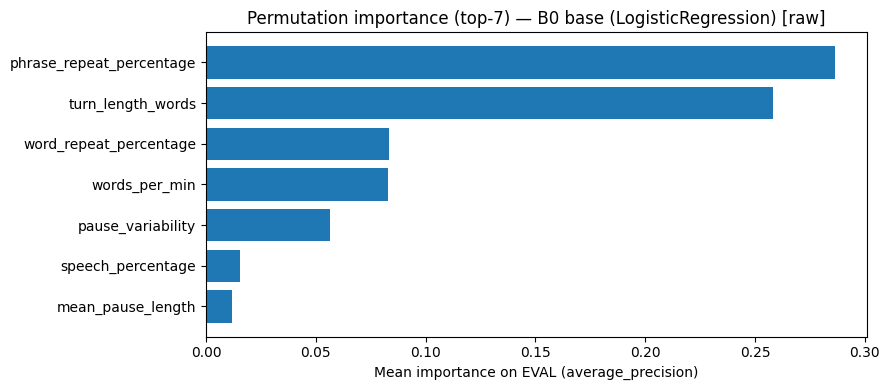


=== L base: LogisticRegression [default] ===

Classification report:
               precision    recall  f1-score   support

           0      0.731     0.543     0.623        35
           1      0.467     0.667     0.549        21

    accuracy                          0.589        56
   macro avg      0.599     0.605     0.586        56
weighted avg      0.632     0.589     0.595        56

Confusion matrix:
 [[19 16]
 [ 7 14]]

[L base (LogisticRegression)] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg         0.123734        0.026670
                word_coherence_10_mean         0.062853        0.024934
                         sentiment_pos         0.036793        0.025912
first_order_sentence_tangeniality_mean         0.013107        0.004348
               first_person_percentage         0.012279        0.005317
                              mattr_10      

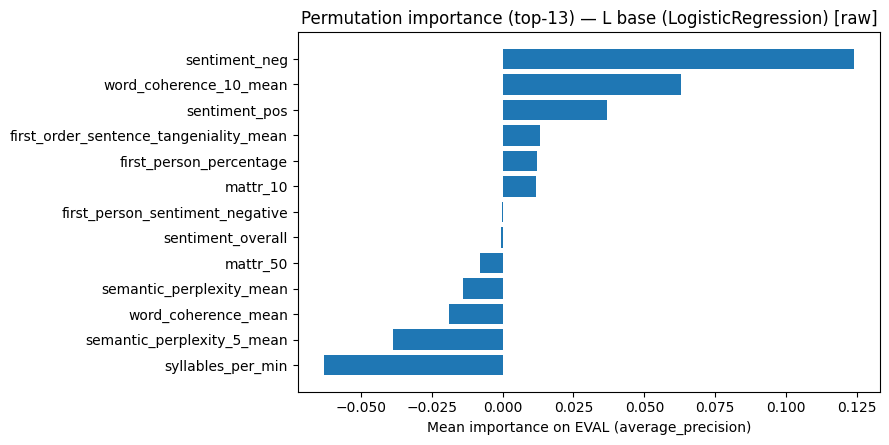


=== FUSED (meta LogisticRegression on [p_B0, p_L]) ===
Meta weights: {'intercept': -1.9115241839758328, 'w_pB0': 1.3166227150276968, 'w_pL': 2.5695599325368863}

Classification report:
               precision    recall  f1-score   support

           0      0.870     0.571     0.690        35
           1      0.545     0.857     0.667        21

    accuracy                          0.679        56
   macro avg      0.708     0.714     0.678        56
weighted avg      0.748     0.679     0.681        56

Confusion matrix:
 [[20 15]
 [ 3 18]]


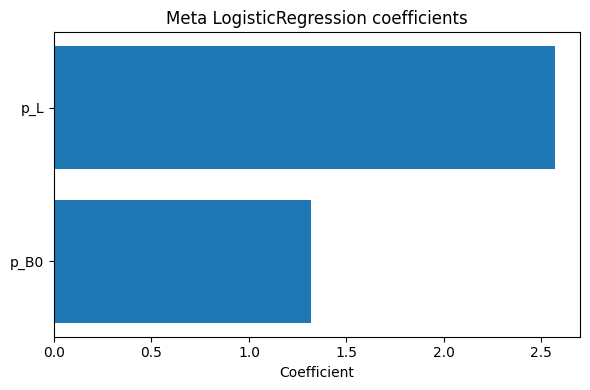


=== Summary metrics on TEST (tuned by PR AUC) ===
  stage                  model  tuned  cv_best_score best_params  n_train  n_test  n_features_raw  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier
B0 base     LogisticRegression  False            NaN                  219      56               7    0.6607    0.6606 0.5357 0.7678        0.7000   0.7755  0.6339  0.8980  0.7007 0.2137
 L base     LogisticRegression  False            NaN                  219      56              13    0.5893    0.5860 0.4581 0.7110        0.6048   0.6490  0.4952  0.7946  0.4715 0.2627
  FUSED MetaLogisticRegression  False            NaN  meta_C=1.0      219      56               2    0.6786    0.6782 0.5534 0.7846        0.7143   0.7252  0.5850  0.8544  0.6212 0.2293


In [3]:
res = run_late_fusion_pipeline_clean(
    dataset_b0_path=f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    dataset_l_path=f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    base_model_b0="LogisticRegression",
    base_model_l="LogisticRegression",
    tune_tree_models=False,
    compute_importance=True,
    # feature_selection=False,  # set True to do train-only raw-column selection per modality
    target_col='PTSD_label',
)

In [5]:
res

,stage,model,tuned,cv_best_score,best_params,n_train,n_test,n_features_raw,accuracy,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier
0,B0 base,LogisticRegression,False,NaN,,219,56,7,0.660714,0.660606,0.535714,0.767783,0.700000,0.77551,0.633946,0.897959,0.700697,0.213660
1,L base,LogisticRegression,False,NaN,,219,56,13,0.589286,0.585985,0.458065,0.710968,0.604762,0.64898,0.495238,0.794592,0.471478,0.262708
2,FUSED,MetaLogisticRegression,False,NaN,meta_C=1.0,219,56,2,0.678571,0.678161,0.553429,0.784615,0.714286,0.72517,0.585034,0.854422,0.621228,0.229273
